# Brasil em dados: panorama de finanças públicas e políticas públicas

Este estudo reúne os gráficos trabalhados no painel Insights Brasil em uma apresentação contínua. A sequência percorre endividamento, juros, orçamento, proteção social, atividade econômica, tributos e poder de compra.

Os gráficos são produzidos a partir do mesmo bundle local que alimenta o site. Cada página informa o que a métrica representa, como interpretá-la e de onde vem a série. As células de código ficam ocultas na versão PDF.

**Como gerar:** na raiz do projeto, execute `make pdf`. O arquivo produzido é `artifacts/apresentacao_insights_brasil.pdf`. Para explorar as figuras e as notas em Jupyter, abra este notebook com `uv run jupyter lab`.

**Escopo:** observações finais variam entre bases. Este relatório registra a data final disponível em cada página; as séries podem ser revistas por seus órgãos responsáveis.

In [1]:
from pathlib import Path
import gzip
import json
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import FuncFormatter
from IPython.display import display
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / "web/src/assets/data/dashboard.json.gz").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "web/src/assets/data/dashboard.json.gz").exists():
    raise FileNotFoundError("Bundle do painel ausente. Execute: uv run python web/scripts/build_data.py")
with gzip.open(ROOT / "web/src/assets/data/dashboard.json.gz", "rt", encoding="utf-8") as f:
    D = json.load(f)

OUT = ROOT / "artifacts/apresentacao_insights_brasil.pdf"
OUT.parent.mkdir(parents=True, exist_ok=True)
BG, PAPER, NAVY = "#10171d", "#18232b", "#9fc4df"
INK, MUTED, GRID = "#e2eaee", "#a7b4bb", "#2a3741"
TEAL, CORAL, GOLD = "#58c2b0", "#ef927d", "#e5bd68"
BLUE, SLATE, GREEN = "#9fc4df", "#aab8c1", "#8bc6a5"
COLORS = [NAVY, TEAL, CORAL, GOLD, BLUE, GREEN, SLATE]
plt.rcParams.update({"font.family":"DejaVu Sans", "font.size":9, "text.color":INK,
    "axes.labelcolor":MUTED, "xtick.color":MUTED, "ytick.color":MUTED,
    "axes.edgecolor":"#3b4a55", "axes.linewidth":.7, "axes.facecolor":PAPER,
    "axes.grid":True, "grid.color":GRID, "grid.linewidth":.8, "figure.facecolor":BG,
    "savefig.facecolor":BG})
PDF = PdfPages(OUT, metadata={"Title":"Brasil em dados — Insights Brasil",
    "Author":"Insights Brasil", "Subject":"Gráficos de dados públicos oficiais"})
PAGE = 0

def br(value, digits=1):
    return f"{value:,.{digits}f}".replace(",", "X").replace(".", ",").replace("X", ".")
def pct(value, digits=1): return br(value, digits) + "%"
def tri(bilhoes): return "R$ " + br(bilhoes/1000) + " tri"
def axis_style(ax, percent=False):
    ax.set_facecolor(PAPER); ax.grid(axis="y", color=GRID, linewidth=.8); ax.set_axisbelow(True)
    ax.spines[["top","right","left"]].set_visible(False); ax.spines["bottom"].set_color("#3b4a55")
    ax.tick_params(axis="both", labelsize=8, length=0, pad=6)
    if percent: ax.axhline(0, color="#aebbb8", lw=.8, zorder=0)
def make_page(section, title, what, reading, source, period, chart_top=.61):
    global PAGE
    PAGE += 1
    fig=plt.figure(figsize=(13.333,7.5), facecolor=BG)
    fig.text(.065,.94,section.upper(),color=TEAL,fontsize=8,weight="bold",family="DejaVu Sans Mono",va="top")
    fig.text(.065,.895,title,color=INK,fontsize=22,weight="bold",va="top")
    fig.text(.065,.825,"O QUE MOSTRA",color=TEAL,fontsize=7,weight="bold",family="DejaVu Sans Mono",va="top")
    fig.text(.17,.825,what,color=INK,fontsize=8.4,va="top",wrap=True)
    fig.text(.065,.755,"COMO LER",color=CORAL,fontsize=7,weight="bold",family="DejaVu Sans Mono",va="top")
    fig.text(.17,.755,reading,color=INK,fontsize=8.4,va="top",wrap=True)
    fig.add_artist(plt.Line2D([.065,.935],[.70,.70],transform=fig.transFigure,color="#2a3741",lw=.8))
    ax=fig.add_axes([.085,.19,.83,.47 if chart_top <= .62 else .51])
    ax.set_facecolor(PAPER)
    fig.text(.065,.095,source,color=MUTED,fontsize=7.2,va="bottom")
    fig.text(.065,.067,"PERÍODO  ·  "+str(period),color=MUTED,fontsize=7,family="DejaVu Sans Mono",va="bottom")
    fig.text(.935,.035,f"INSIGHTS BRASIL  ·  {PAGE:02d}",color="#829098",fontsize=7,family="DejaVu Sans Mono",ha="right")
    return fig,ax
def finish(fig):
    PDF.savefig(fig, bbox_inches=None, facecolor=fig.get_facecolor(), transparent=False)
    display(fig)
    plt.close(fig)
def legend(ax, **kwargs):
    ax.legend(frameon=False, fontsize=8, **kwargs)
def year_ticks(ax, every=2):
    ax.xaxis.set_major_locator(mdates.YearLocator(every)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
def categorical_ticks(ax, labels, max_ticks=14):
    step=max(1, int(np.ceil(len(labels)/max_ticks)))
    ticks=np.arange(0,len(labels),step)
    ax.set_xticks(ticks); ax.set_xticklabels([labels[i] for i in ticks], rotation=0, ha="center")
def source_period(rows, date_key, source):
    return f"{source}  ·  {rows[0][date_key]} a {rows[-1][date_key]}"

print(f"Bundle atualizado em {D.get('updated','—')} · dados carregados de forma local")

Bundle atualizado em 2026-10-06 · dados carregados de forma local


## Capa

Um panorama visual dos indicadores que ajudam a entender o tamanho da dívida, o custo dos juros, a execução do orçamento e a evolução econômica e social. Valores e conceitos têm escopos diferentes; as notas acompanham cada gráfico.

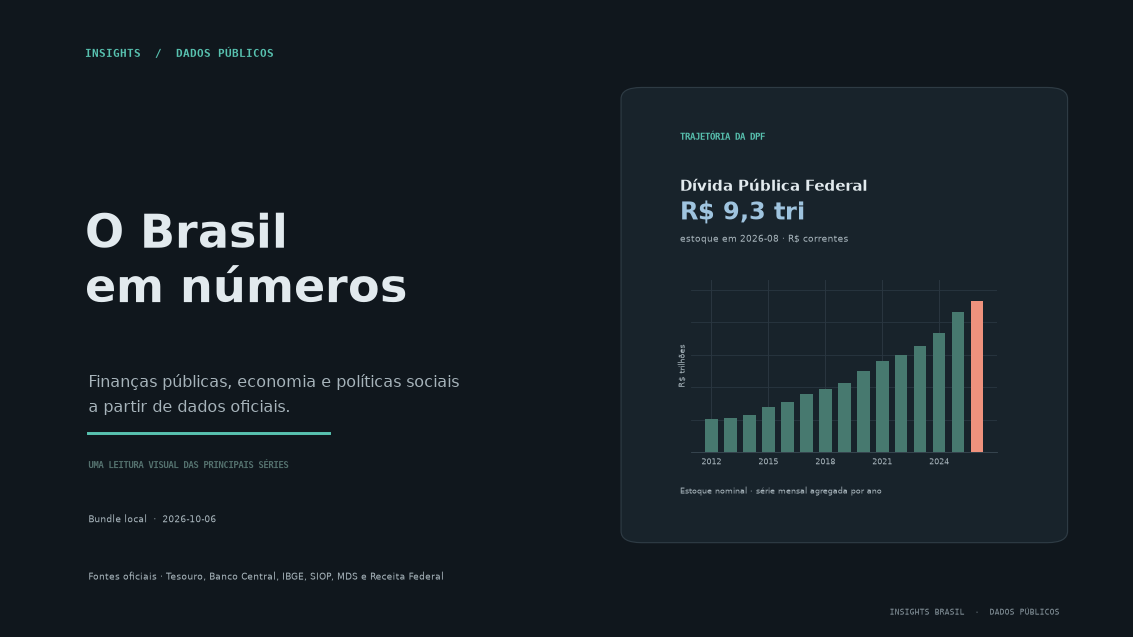

In [2]:
fig=plt.figure(figsize=(13.333,7.5),facecolor=BG)
fig.text(.075,.91,"INSIGHTS  /  DADOS PÚBLICOS",color=TEAL,fontsize=9,family="DejaVu Sans Mono",weight="bold")
fig.text(.075,.68,"O Brasil\nem números",color=INK,fontsize=39,weight="bold",linespacing=1.16,va="top")
fig.text(.078,.42,"Finanças públicas, economia e políticas sociais\na partir de dados oficiais.",color=MUTED,fontsize=13.5,linespacing=1.6,va="top")
fig.add_artist(plt.Line2D([.078,.29],[.32,.32],color=TEAL,lw=2.5))
fig.text(.078,.265,"UMA LEITURA VISUAL DAS PRINCIPAIS SÉRIES",color="#54716e",fontsize=8,family="DejaVu Sans Mono",weight="bold")
fig.text(.078,.18,"Bundle local  ·  "+str(D.get("updated","—")),color=MUTED,fontsize=8)
fig.text(.078,.09,"Fontes oficiais · Tesouro, Banco Central, IBGE, SIOP, MDS e Receita Federal",color=MUTED,fontsize=8)

# Card de dados com uma amostra real da série de estoque da DPF.
from matplotlib.patches import FancyBboxPatch
panel=FancyBboxPatch((.56,.16),.37,.69,transform=fig.transFigure,
    boxstyle="round,pad=.012,rounding_size=.018",facecolor=PAPER,edgecolor="#2e3b44",linewidth=1)
panel.set_zorder(0)
fig.add_artist(panel)
fig.text(.60,.78,"TRAJETÓRIA DA DPF",color=TEAL,fontsize=8,weight="bold",family="DejaVu Sans Mono")
monthly=D["debt"]["monthly"]
latest=monthly[-1]
fig.text(.60,.70,"Dívida Pública Federal",color=INK,fontsize=13,weight="bold")
fig.text(.60,.655,tri(latest["dpf_bilhoes"]),color=NAVY,fontsize=20,weight="bold")
fig.text(.60,.62,"estoque em "+latest["data"][:7]+" · R$ correntes",color=MUTED,fontsize=8)
annual={}
for row in monthly:
    annual[row["data"][:4]]=row
plotrows=[r for r in annual.values() if int(r["data"][:4])>=2012]
ax=fig.add_axes([.61,.29,.27,.27])
ax.set_zorder(1)
ax.set_facecolor(PAPER)
years=[int(r["data"][:4]) for r in plotrows]
values=[r["dpf_bilhoes"]/1000 for r in plotrows]
colors=["#47796f"]*(len(values)-1)+[CORAL]
ax.bar(years,values,color=colors,width=.66,zorder=3)
ax.set_ylim(0,max(values)*1.14)
ax.grid(axis="y",color="#2a3741",linewidth=.7);ax.set_axisbelow(True)
ax.spines[["top","right","left"]].set_visible(False);ax.spines["bottom"].set_color("#3b4a55")
ax.tick_params(axis="y",left=False,labelleft=False);ax.tick_params(axis="x",length=0,pad=5,labelsize=7,colors=MUTED)
step=max(1,len(years)//5);ax.set_xticks(years[::step])
ax.set_ylabel("R$ trilhões",fontsize=7,color=MUTED,labelpad=4)
fig.text(.60,.225,"Estoque nominal · série mensal agregada por ano",color=MUTED,fontsize=7)
fig.text(.935,.035,"INSIGHTS BRASIL  ·  DADOS PÚBLICOS",color="#829098",fontsize=7,family="DejaVu Sans Mono",ha="right")
PAGE += 1
PDF.savefig(fig,facecolor=fig.get_facecolor(),transparent=False)
display(fig)
plt.close(fig)

## Estoque e composição da dívida pública federal

**O que representa.** Saldo mensal da Dívida Pública Federal (DPF), dividido em dívida interna (DPMFi) e externa (DPFe), em reais correntes.

**Interpretação e importância.** A DPF total é o estoque sob responsabilidade do Tesouro. A alta do saldo pode refletir juros, emissões líquidas, câmbio e ajustes; o gráfico não desconta a inflação. As duas parcelas compõem o total.

**Para aprofundar.** Títulos públicos, indexadores, prazo médio, resultado primário e fatores de variação da dívida.

Fonte: Tesouro Nacional · estoque mensal da DPF.

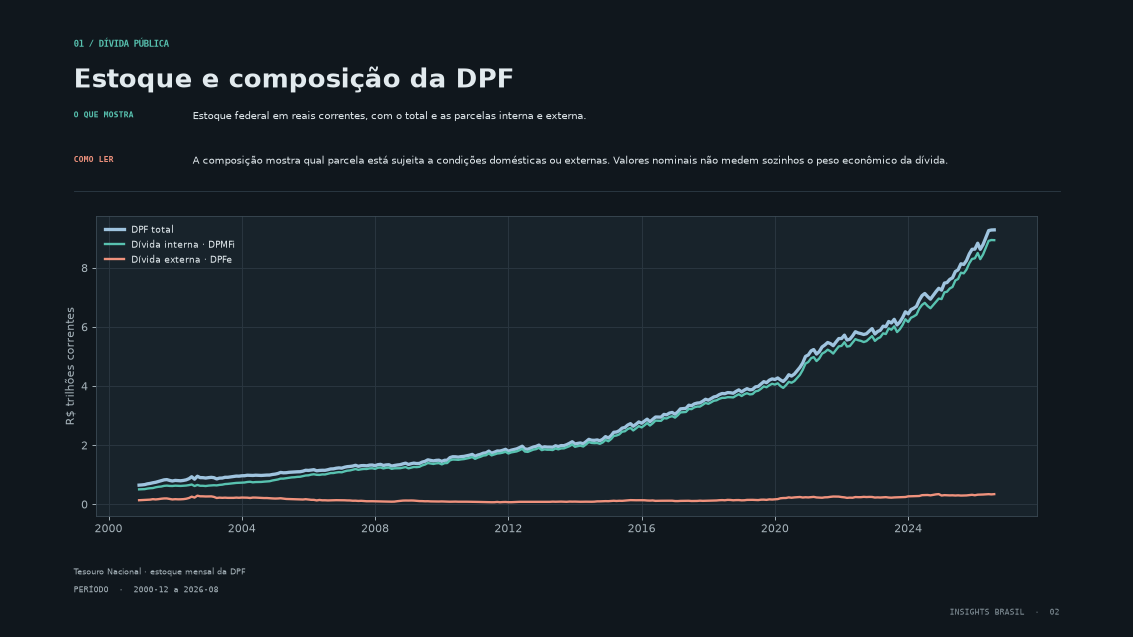

In [3]:
rows=D["debt"]["monthly"]; dates=pd.to_datetime([r["data"] for r in rows])
fig,ax=make_page("01 / Dívida pública","Estoque e composição da DPF",
"Estoque federal em reais correntes, com o total e as parcelas interna e externa.",
"A composição mostra qual parcela está sujeita a condições domésticas ou externas. Valores nominais não medem sozinhos o peso econômico da dívida.","Tesouro Nacional · estoque mensal da DPF",f"{rows[0]['data'][:7]} a {rows[-1]['data'][:7]}")
for key,name,color,width in [("dpf_bilhoes","DPF total",NAVY,2.8),("dpmfi_bilhoes","Dívida interna · DPMFi",TEAL,2),("dpfe_bilhoes","Dívida externa · DPFe",CORAL,2)]:
    ax.plot(dates,[r[key]/1000 for r in rows],color=color,lw=width,label=name)
ax.set_ylabel("R$ trilhões correntes");year_ticks(ax,4);legend(ax,loc="upper left");finish(fig)

## Dívida bruta e líquida em proporção do PIB

**O que representa.** DBGG e DLGG divulgadas pelo Banco Central para o Governo Geral, como percentual do PIB.

**Interpretação e importância.** O perímetro inclui governos federal, estaduais e municipais. DBGG e DLGG são conceitos distintos da DPF do Tesouro; a razão relaciona dívida e tamanho da economia, mas também varia com o PIB, câmbio e ajustes fiscais.

**Para aprofundar.** Metodologia fiscal do Banco Central, dívida bruta e líquida, PIB nominal e dinâmica da dívida.

Fonte: Banco Central · séries SGS 13762 e SGS 4536.

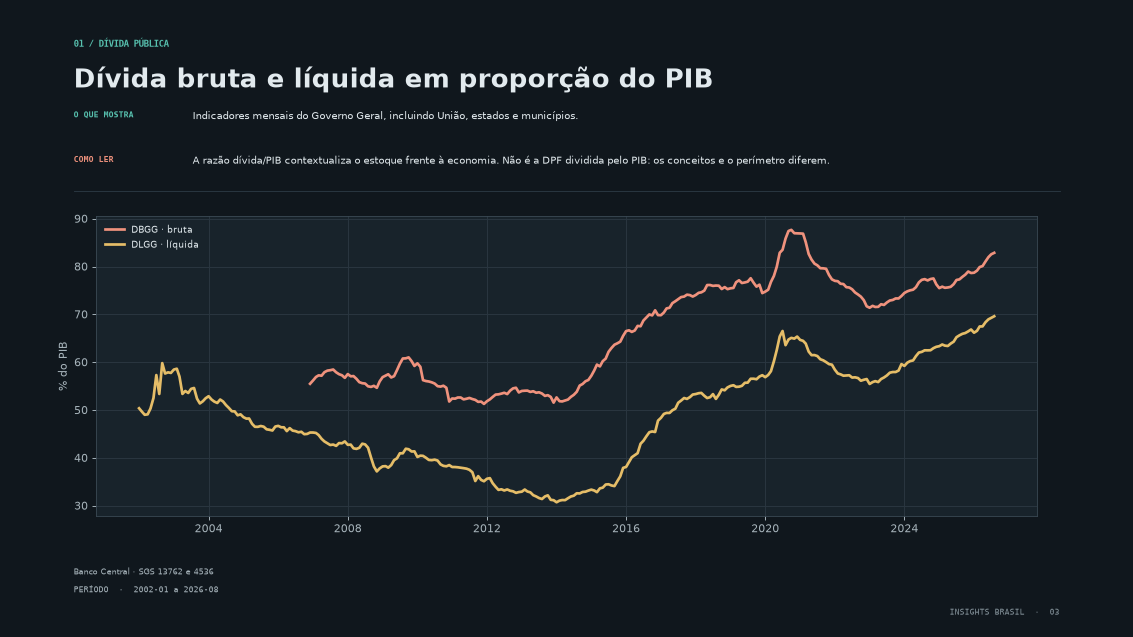

In [4]:
rows=[r for r in D["debt"]["macro"] if r.get("dbgg_percentual_pib") is not None or r.get("dlgg_percentual_pib") is not None]
fig,ax=make_page("01 / Dívida pública","Dívida bruta e líquida em proporção do PIB",
"Indicadores mensais do Governo Geral, incluindo União, estados e municípios.",
"A razão dívida/PIB contextualiza o estoque frente à economia. Não é a DPF dividida pelo PIB: os conceitos e o perímetro diferem.","Banco Central · SGS 13762 e 4536",f"{rows[0]['data'][:7]} a {rows[-1]['data'][:7]}")
dates=pd.to_datetime([r["data"] for r in rows])
for key,name,color in [("dbgg_percentual_pib","DBGG · bruta",CORAL),("dlgg_percentual_pib","DLGG · líquida",GOLD)]:
    ax.plot(dates,[r[key] if r[key] is not None else np.nan for r in rows],lw=2.3,color=color,label=name)
ax.set_ylabel("% do PIB");year_ticks(ax,4);legend(ax,loc="upper left");finish(fig)

## Fatores de variação do estoque da DPF

**O que representa.** Contribuições mensais divulgadas pelo Tesouro, incluindo juros apropriados, emissão/resgate líquido e total dos fatores.

**Interpretação e importância.** Os fatores ajudam a distinguir juros e gestão do passivo de captação líquida. A leitura é por competência e deve respeitar as definições do relatório do Tesouro; não atribua toda mudança do estoque a novas despesas.

**Para aprofundar.** Emissão e resgate de títulos, contabilidade por competência, resultado primário e metodologia de fatores da DPF.

Fonte: Tesouro Nacional · fatores mensais da DPF.

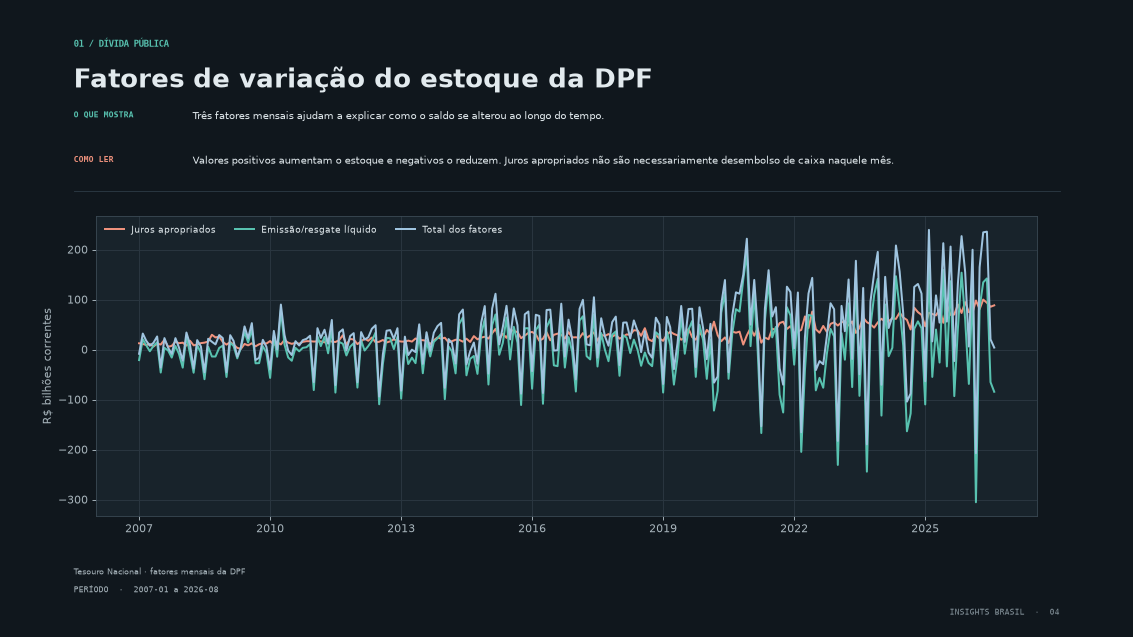

In [5]:
rows=D["debt"]["factors"]
series=[("I.2 - Juros  Apropriados","Juros apropriados",CORAL),("I.1 - Emissão/Resgate Líquido","Emissão/resgate líquido",TEAL),("Total dos Fatores (I + II)","Total dos fatores",NAVY)]
fig,ax=make_page("01 / Dívida pública","Fatores de variação do estoque da DPF",
"Três fatores mensais ajudam a explicar como o saldo se alterou ao longo do tempo.",
"Valores positivos aumentam o estoque e negativos o reduzem. Juros apropriados não são necessariamente desembolso de caixa naquele mês.","Tesouro Nacional · fatores mensais da DPF",f"{rows[0]['data'][:7]} a {rows[-1]['data'][:7]}")
for key,name,color in series:
    sr=sorted([r for r in rows if r["indicador"]==key],key=lambda r:r["data"])
    ax.plot(pd.to_datetime([r["data"] for r in sr]),[r["valor_r_bilhoes"] for r in sr],lw=1.7,color=color,label=name)
ax.set_ylabel("R$ bilhões correntes");year_ticks(ax,3);legend(ax,loc="upper left",ncol=3);finish(fig)

## Juros apropriados e taxa implícita aproximada

**O que representa.** Barras somam os juros apropriados por ano; a linha apresenta juros divididos pelo estoque médio da DPF nos anos completos.

**Interpretação e importância.** Juros apropriados seguem o regime de competência, não equivalendo necessariamente ao pagamento em caixa. A taxa é uma aproximação analítica do painel e não substitui o custo médio oficial do Tesouro.

**Para aprofundar.** Juros reais e nominais, indexadores, custo médio oficial, estoque médio e risco de refinanciamento.

Fonte: Tesouro Nacional · fatores da DPF e estoque mensal.

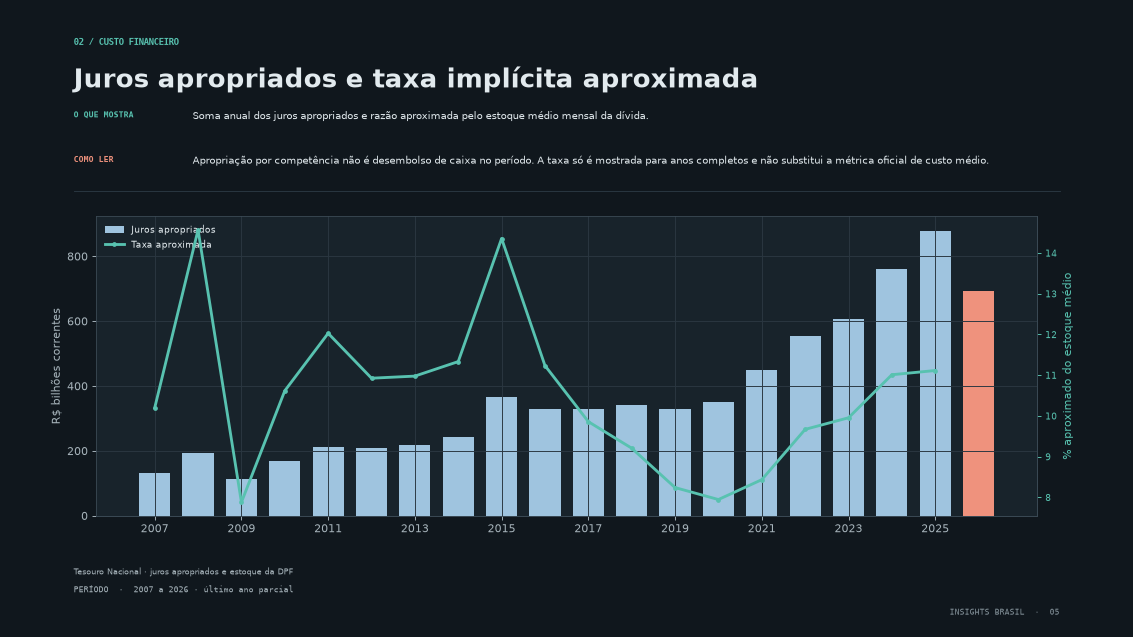

In [6]:
rows=D["debt"]["interest"]["annual"]
fig,ax=make_page("02 / Custo financeiro","Juros apropriados e taxa implícita aproximada",
"Soma anual dos juros apropriados e razão aproximada pelo estoque médio mensal da dívida.",
"Apropriação por competência não é desembolso de caixa no período. A taxa só é mostrada para anos completos e não substitui a métrica oficial de custo médio.","Tesouro Nacional · juros apropriados e estoque da DPF",f"{rows[0]['ano']} a {rows[-1]['ano']} · último ano parcial")
years=[r["ano"] for r in rows]; vals=[r["juros_dpf_bilhoes"] for r in rows]
ax.bar(years,vals,color=[NAVY if y<max(years) else CORAL for y in years],width=.72,label="Juros apropriados")
ax.set_ylabel("R$ bilhões correntes");ax.set_xticks(years[::2]);ax.set_xticklabels(years[::2])
ax2=ax.twinx(); rates=[r["custo_implicito_aproximado_percentual"] for r in rows]
ax2.plot(years,[v if v is not None else np.nan for v in rates],color=TEAL,lw=2.4,marker="o",ms=3,label="Taxa aproximada")
ax2.set_ylabel("% aproximado do estoque médio",color=TEAL);ax2.spines[["top","left"]].set_visible(False);ax2.grid(False);ax2.tick_params(axis="y",colors=TEAL,labelsize=8)
handles,labels=ax.get_legend_handles_labels();h2,l2=ax2.get_legend_handles_labels();ax.legend(handles+h2,labels+l2,frameon=False,fontsize=8,loc="upper left");finish(fig)

## Orçamento federal e políticas sociais

Os valores de execução orçamentária por função estão corrigidos pelo IPCA para reais de 2025, reproduzindo o fator anual usado no site. O detalhamento GND 4 mede investimentos dentro da função, não todo o gasto da política pública.

## Execução paga em saúde, educação e segurança

**O que representa.** Despesa federal paga nas três funções orçamentárias, corrigida para reais médios de 2025 pelo IPCA.

**Interpretação e importância.** A correção de preços torna os anos mais comparáveis em poder de compra. Pagamento difere de dotação, empenho e liquidação; a série não inclui automaticamente despesas estaduais e municipais.

**Para aprofundar.** Ciclo orçamentário, execução por função, empenho/liquidação/pagamento, IPCA e responsabilidades federativas.

Fonte: SIOP · execução federal por função; IPCA/IBGE.

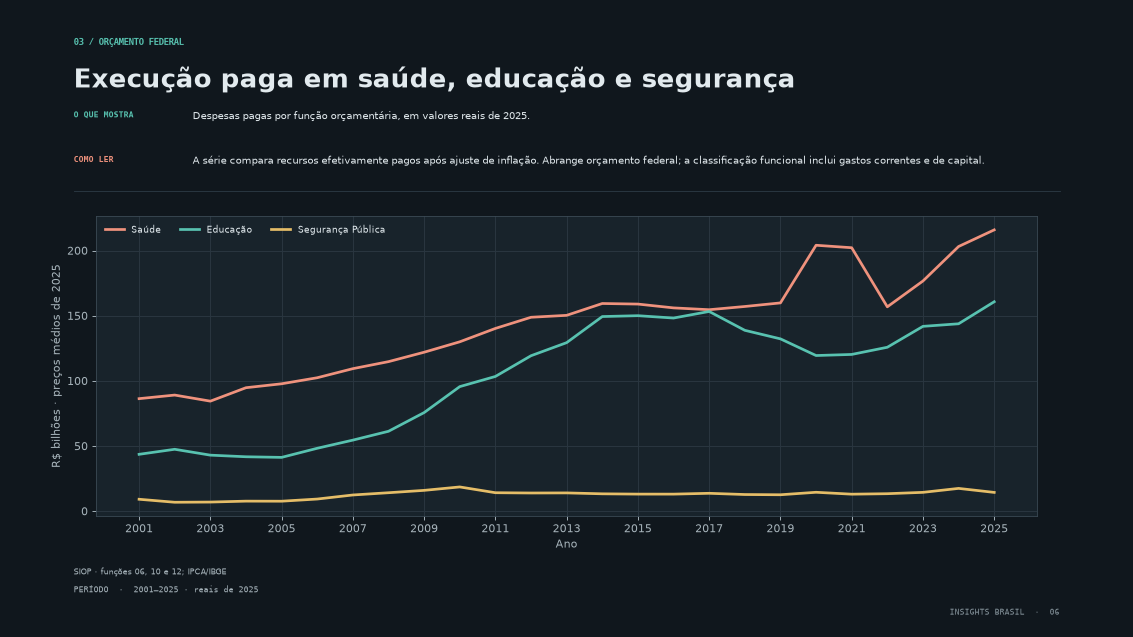

In [7]:
rows=D["spending"]; years=sorted({r["ano"] for r in rows})
months=[r for r in D["debt"]["macro"] if r.get("ipca_variacao_mensal_percentual") is not None]
idx=1.; monthly={}
for r in months:
    idx*=1+r["ipca_variacao_mensal_percentual"]/100; monthly.setdefault(int(r["data"][:4]),[]).append(idx)
means={y:float(np.mean(v)) for y,v in monthly.items()}; ref=means.get(2025,1)
factor={y:ref/v for y,v in means.items()}
fig,ax=make_page("03 / Orçamento federal","Execução paga em saúde, educação e segurança",
"Despesas pagas por função orçamentária, em valores reais de 2025.",
"A série compara recursos efetivamente pagos após ajuste de inflação. Abrange orçamento federal; a classificação funcional inclui gastos correntes e de capital.","SIOP · funções 06, 10 e 12; IPCA/IBGE",f"{min(years)}–{max(years)} · reais de 2025")
for i,name in enumerate(["Saúde","Educação","Segurança Pública"]):
    vals=[]
    for y in years:
        r=next((r for r in rows if r["ano"]==y and r["funcao"].strip()==name),None)
        vals.append(r["despesa_paga_r$"]*factor.get(y,1)/1e9 if r else np.nan)
    ax.plot(years,vals,color=[CORAL,TEAL,GOLD][i],lw=2.3,label=name)
ax.set_ylabel("R$ bilhões · preços médios de 2025");ax.set_xlabel("Ano");ax.set_xticks(years[::2]);legend(ax,loc="upper left",ncol=3);finish(fig)

## GND 4 · Série histórica — investimento de capital pago

**O que representa.** Despesa paga classificada como Grupo de Natureza da Despesa 4 nas mesmas três funções, corrigida para reais de 2025.

**Interpretação e importância.** GND 4 representa investimento dentro do gasto total. Um valor maior não prova, isoladamente, que obras foram concluídas ou serviços melhoraram: execução física e resultados também importam.

**Para aprofundar.** Classificação por GND, investimento público, restos a pagar, execução física e avaliação de projetos.

Fonte: SIOP · GND 4 por função; IPCA/IBGE.

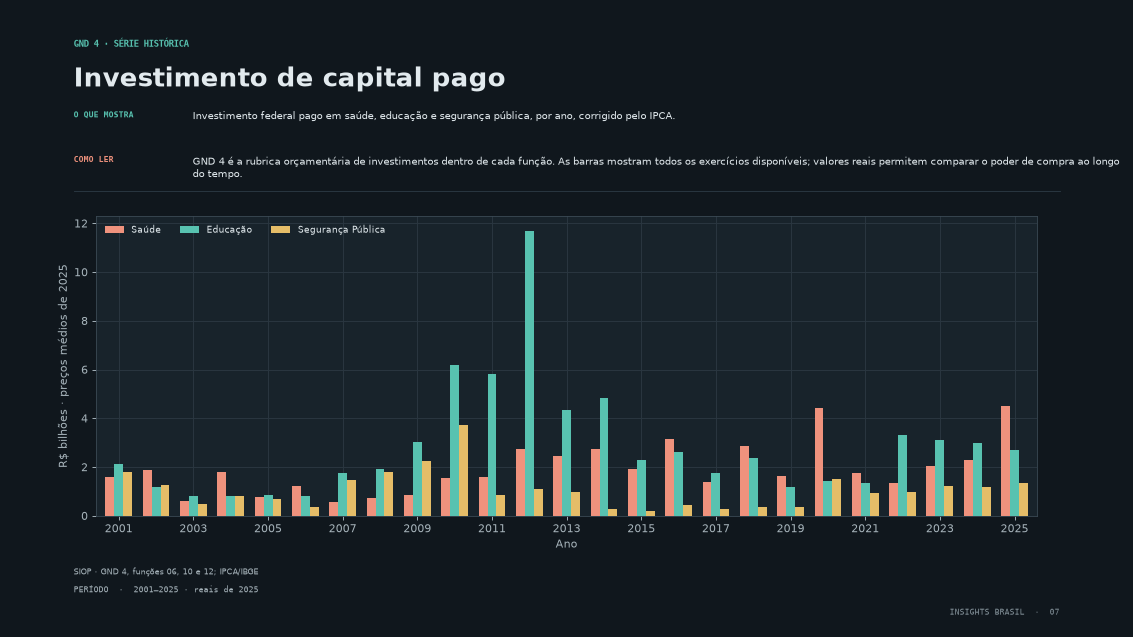

In [8]:
rows=D["spending"]; years=sorted({r["ano"] for r in rows})
fig,ax=make_page("GND 4 · SÉRIE HISTÓRICA","Investimento de capital pago",
"Investimento federal pago em saúde, educação e segurança pública, por ano, corrigido pelo IPCA.",
"GND 4 é a rubrica orçamentária de investimentos dentro de cada função. As barras mostram todos os exercícios disponíveis; valores reais permitem comparar o poder de compra ao longo do tempo.","SIOP · GND 4, funções 06, 10 e 12; IPCA/IBGE",f"{min(years)}–{max(years)} · reais de 2025")
x=np.arange(len(years)); width=.24
for i,name in enumerate(["Saúde","Educação","Segurança Pública"]):
    vals=[]
    for y in years:
        row=next((r for r in rows if r["ano"]==y and r["funcao"].strip()==name),None)
        vals.append(row["gnd4_investimento_pago_r$"]*factor.get(y,1)/1e9 if row else np.nan)
    ax.bar(x+(i-1)*width,vals,width=width,color=[CORAL,TEAL,GOLD][i],label=name,zorder=3)
ax.set_ylabel("R$ bilhões · preços médios de 2025");ax.set_xlabel("Ano")
ax.set_xticks(x[::2]);ax.set_xticklabels([str(y) for y in years[::2]])
ax.set_xlim(-.6,len(years)-.4);legend(ax,loc="upper left",ncol=3);finish(fig)

## Beneficiários do BPC por grupo

**O que representa.** Pessoas beneficiárias do Benefício de Prestação Continuada, separadas entre pessoas com deficiência e pessoas idosas.

**Interpretação e importância.** A série acompanha a cobertura administrativa. Demografia, regras de elegibilidade, concessões e revisões cadastrais podem alterar os números; não mede pobreza nem impacto causal por si só.

**Para aprofundar.** LOAS, critérios do BPC, envelhecimento, deficiência, cobertura e avaliação de políticas sociais.

Fonte: MDS · VIS DATA · histórico agregado do BPC.

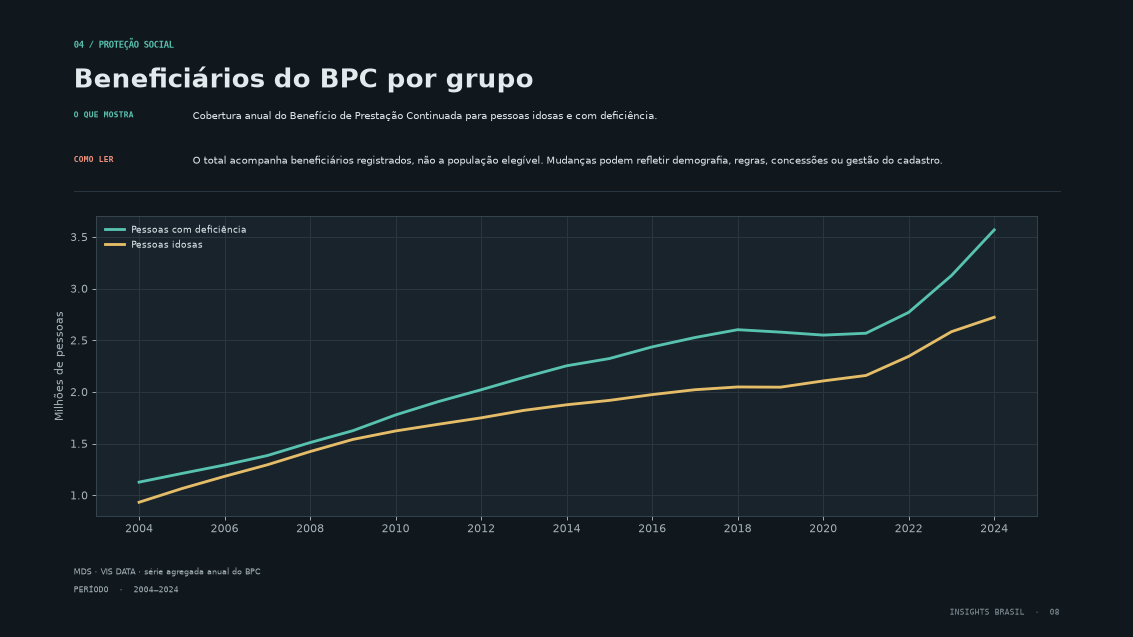

In [9]:
rows=D["social"]["bpc_annual"]; years=[r["ano"] for r in rows]
fig,ax=make_page("04 / Proteção social","Beneficiários do BPC por grupo",
"Cobertura anual do Benefício de Prestação Continuada para pessoas idosas e com deficiência.",
"O total acompanha beneficiários registrados, não a população elegível. Mudanças podem refletir demografia, regras, concessões ou gestão do cadastro.","MDS · VIS DATA · série agregada anual do BPC",f"{years[0]}–{years[-1]}")
for key,label,color in [("beneficiarios_pcd","Pessoas com deficiência",TEAL),("beneficiarios_idosos","Pessoas idosas",GOLD)]:
    ax.plot(years,[r[key]/1e6 for r in rows],color=color,lw=2.4,label=label)
ax.set_ylabel("Milhões de pessoas");ax.set_xticks(years[::2]);legend(ax,loc="upper left");finish(fig)

## Repasses históricos do BPC por grupo

A série anual do MDS/VIS DATA também traz os repasses para pessoas idosas e pessoas com deficiência. Este gráfico mostra os valores nominais, sem corrigir a inflação; portanto, a tendência combina aumento de cobertura, reajustes do salário mínimo e mudanças no nível de preços. A soma das parcelas representa o total anual reportado.

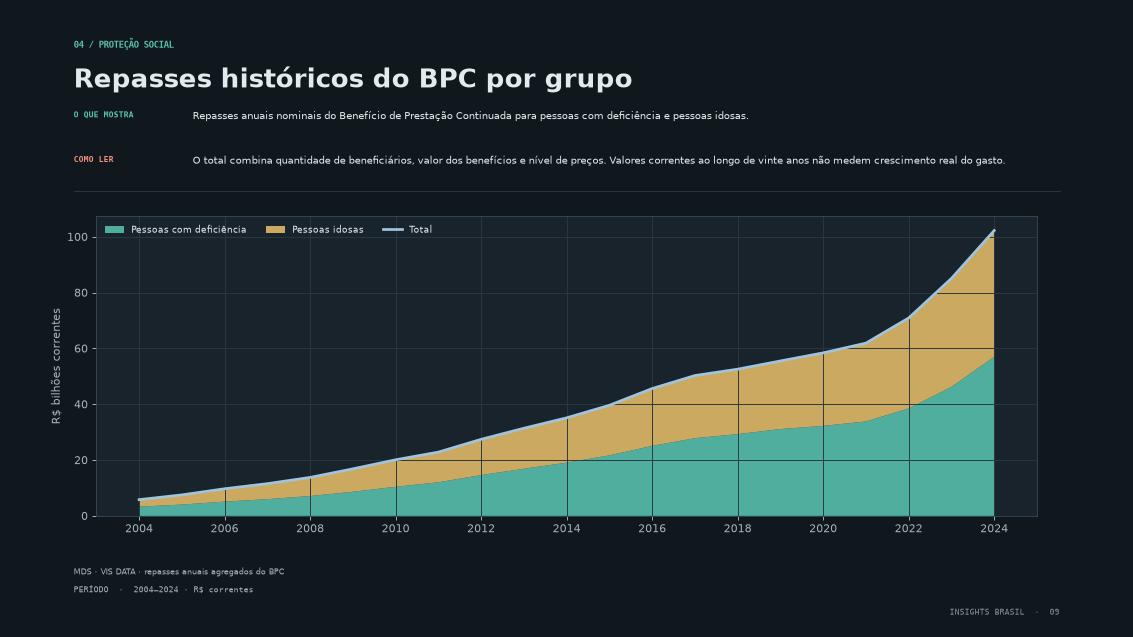

In [10]:
rows=D["social"]["bpc_annual"]; years=[r["ano"] for r in rows]
fig,ax=make_page("04 / Proteção social","Repasses históricos do BPC por grupo",
"Repasses anuais nominais do Benefício de Prestação Continuada para pessoas com deficiência e pessoas idosas.",
"O total combina quantidade de beneficiários, valor dos benefícios e nível de preços. Valores correntes ao longo de vinte anos não medem crescimento real do gasto.","MDS · VIS DATA · repasses anuais agregados do BPC",f"{years[0]}–{years[-1]} · R$ correntes")
pcd=np.array([r["repasse_pcd_brl"]/1e9 for r in rows]); idosos=np.array([r["repasse_idosos_brl"]/1e9 for r in rows])
total=pcd+idosos
ax.stackplot(years,pcd,idosos,labels=["Pessoas com deficiência","Pessoas idosas"],colors=[TEAL,GOLD],alpha=.88)
ax.plot(years,total,color=NAVY,lw=2.3,label="Total")
ax.set_ylabel("R$ bilhões correntes");ax.set_xticks(years[::2]);legend(ax,loc="upper left",ncol=3);finish(fig)

## Repasses do BPC em valores reais

A série seguinte corrige os repasses nominais pelo IPCA e expressa os valores em reais médios de 2025, usando o mesmo deflator anual do painel. Isso permite comparar a evolução do poder de compra dos recursos. A correção não mede o impacto social do benefício nem substitui a análise de cobertura, que aparece no gráfico anterior.

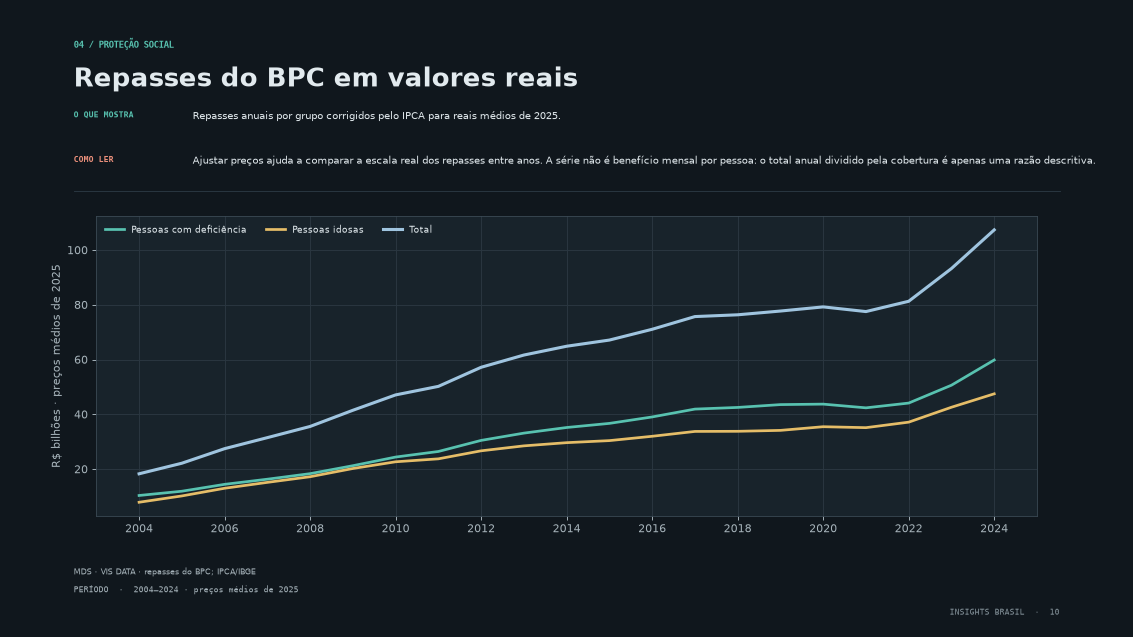

In [11]:
rows=D["social"]["bpc_annual"]; years=[r["ano"] for r in rows]
idx=1.; monthly={}
for r in D["debt"]["macro"]:
    if r.get("ipca_variacao_mensal_percentual") is not None:
        idx*=1+r["ipca_variacao_mensal_percentual"]/100
        monthly.setdefault(int(r["data"][:4]),[]).append(idx)
means={y:float(np.mean(v)) for y,v in monthly.items()}; reference=means.get(2025,1.)
fac={y:reference/v for y,v in means.items()}
fig,ax=make_page("04 / Proteção social","Repasses do BPC em valores reais",
"Repasses anuais por grupo corrigidos pelo IPCA para reais médios de 2025.",
"Ajustar preços ajuda a comparar a escala real dos repasses entre anos. A série não é benefício mensal por pessoa: o total anual dividido pela cobertura é apenas uma razão descritiva.","MDS · VIS DATA · repasses do BPC; IPCA/IBGE",f"{years[0]}–{years[-1]} · preços médios de 2025")
for key,label,color in [("repasse_pcd_brl","Pessoas com deficiência",TEAL),("repasse_idosos_brl","Pessoas idosas",GOLD)]:
    values=[r[key]*fac.get(r["ano"],1)/1e9 for r in rows]
    ax.plot(years,values,color=color,lw=2.3,label=label)
total=[(r["repasse_pcd_brl"]+r["repasse_idosos_brl"])*fac.get(r["ano"],1)/1e9 for r in rows]
ax.plot(years,total,color=NAVY,lw=2.6,label="Total")
ax.set_ylabel("R$ bilhões · preços médios de 2025");ax.set_xticks(years[::2]);legend(ax,loc="upper left",ncol=3);finish(fig)

## Repasses informados para Bolsa Família e BPC

**O que representa.** Valores nominais de repasses reportados em 2024 para Bolsa Família e Benefício de Prestação Continuada.

**Interpretação e importância.** A comparação contextualiza escala fiscal, mas combina fontes e perímetros diferentes. Famílias contempladas pelo Bolsa Família e indivíduos beneficiários do BPC não são unidades comparáveis.

**Para aprofundar.** Transferências condicionadas e assistenciais, cobertura, focalização, benefícios e indicadores de pobreza.

Fonte: MDS · balanço 2024 e VIS DATA/MDS.

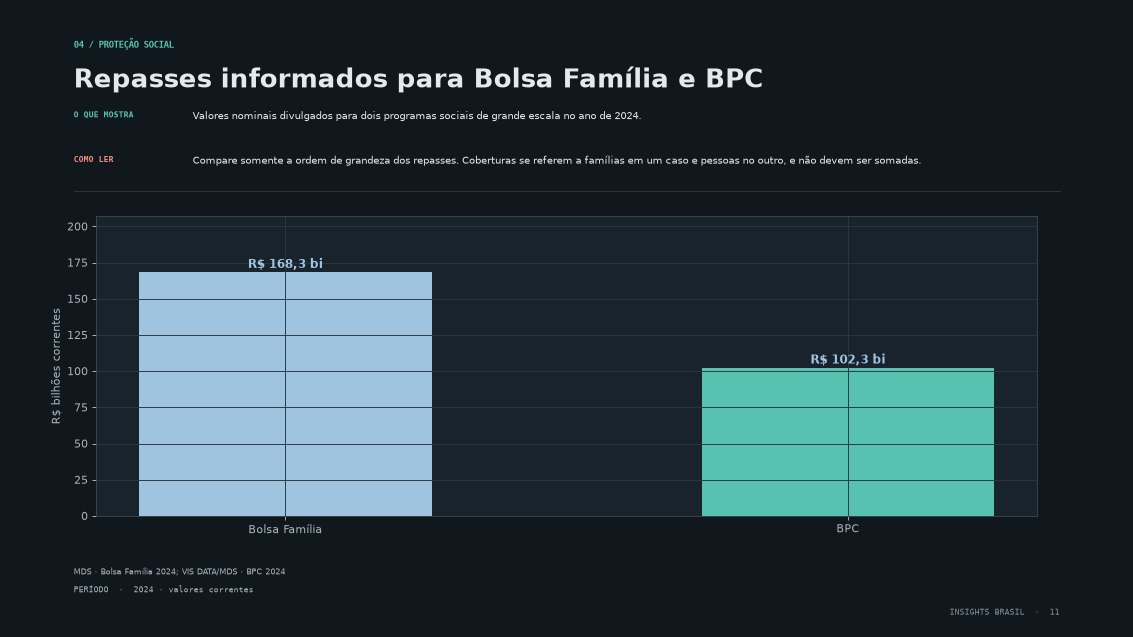

In [12]:
rows=D["social"]["comparison_2024"]
fig,ax=make_page("04 / Proteção social","Repasses informados para Bolsa Família e BPC",
"Valores nominais divulgados para dois programas sociais de grande escala no ano de 2024.",
"Compare somente a ordem de grandeza dos repasses. Coberturas se referem a famílias em um caso e pessoas no outro, e não devem ser somadas.","MDS · Bolsa Família 2024; VIS DATA/MDS · BPC 2024","2024 · valores correntes")
labels=[r["programa"] for r in rows];vals=[r["repasses_brl"]/1e9 for r in rows]
bars=ax.bar(labels,vals,color=[NAVY,TEAL],width=.52)
ax.set_ylabel("R$ bilhões correntes")
for bar,val in zip(bars,vals):ax.text(bar.get_x()+bar.get_width()/2,val+3,"R$ "+br(val,1)+" bi",ha="center",fontsize=10,color=NAVY,weight="bold")
ax.set_ylim(0,max(vals)*1.23);finish(fig)

## Produto Interno Bruto

As três visualizações de frequência disponíveis no painel são reunidas aqui para o PIB nominal, as taxas de volume real e os componentes da despesa. As taxas oficiais não são intercambiáveis; nos gráficos semestrais, as comparações de volume são derivadas pela metodologia descrita em data/README.md.

## PIB nominal — visão trimestral

**O que representa.** PIB a preços correntes e valores setoriais agregados por trimestral segundo as Contas Nacionais Trimestrais.

**Interpretação e importância.** Valores nominais misturam preços e quantidades. Agropecuária, indústria e serviços são parcelas da economia e aparecem para escala; não se somam novamente ao PIB. Os agregados anual e semestral somam trimestres.

**Para aprofundar.** Contas Nacionais, valor adicionado, preços correntes, índice de volume e deflator do PIB.

Fonte: IBGE/SIDRA · Contas Nacionais Trimestrais.

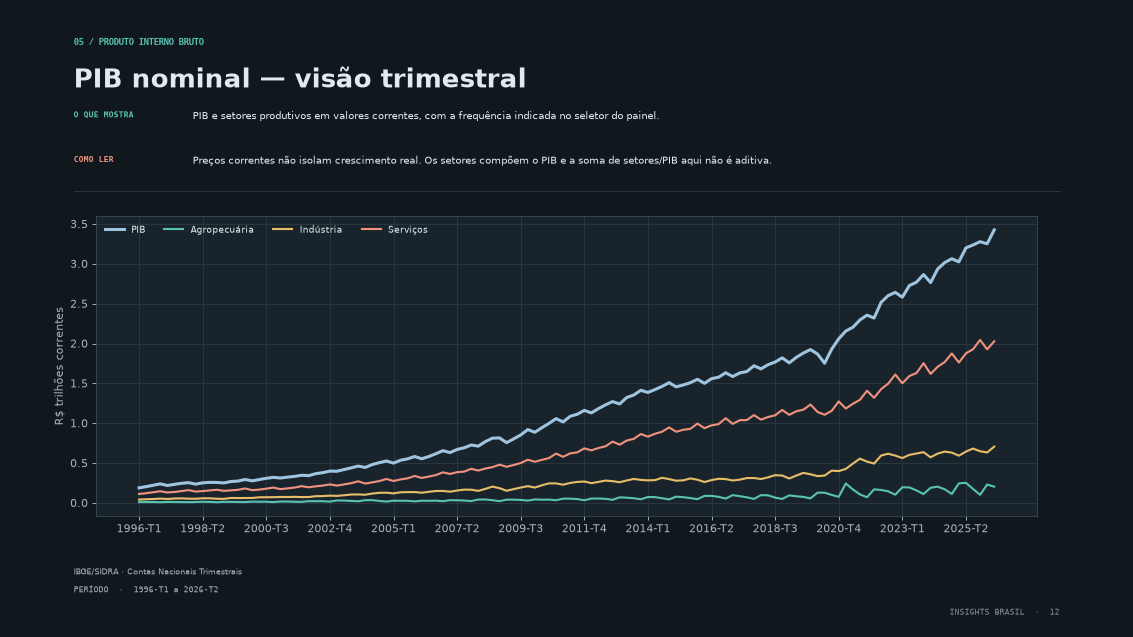

In [13]:
typ='trimestre'
if typ=="trimestre":
    rows=D["pib"]["quarterly"]; labels=[r["trimestre"] for r in rows]; years=[r["ano"] for r in rows]
else:
    rows=[r for r in D["pib"]["aggregates"] if r["tipo_periodo"]==typ and r.get("periodo_completo")]
    labels=[r["periodo"] for r in rows]; years=[r["ano"] for r in rows]
fig,ax=make_page("05 / Produto Interno Bruto",'PIB nominal — visão trimestral',
"PIB e setores produtivos em valores correntes, com a frequência indicada no seletor do painel.",
"Preços correntes não isolam crescimento real. Os setores compõem o PIB e a soma de setores/PIB aqui não é aditiva.","IBGE/SIDRA · Contas Nacionais Trimestrais",f"{labels[0]} a {labels[-1]}")
x=np.arange(len(rows))
for slug,name,color,width in [("pib","PIB",NAVY,2.6),("agropecuaria","Agropecuária",TEAL,1.8),("industria","Indústria",GOLD,1.8),("servicos","Serviços",CORAL,1.8)]:
    vals=[r.get(slug+"_nominal_milhoes")/1e6 if r.get(slug+"_nominal_milhoes") is not None else np.nan for r in rows]
    ax.plot(x,vals,color=color,lw=width,label=name)
categorical_ticks(ax,labels,14);ax.set_ylabel("R$ trilhões correntes");legend(ax,loc="upper left",ncol=4);finish(fig)

## PIB nominal — visão semestral

**O que representa.** PIB a preços correntes e valores setoriais agregados por semestral segundo as Contas Nacionais Trimestrais.

**Interpretação e importância.** Valores nominais misturam preços e quantidades. Agropecuária, indústria e serviços são parcelas da economia e aparecem para escala; não se somam novamente ao PIB. Os agregados anual e semestral somam trimestres.

**Para aprofundar.** Contas Nacionais, valor adicionado, preços correntes, índice de volume e deflator do PIB.

Fonte: IBGE/SIDRA · Contas Nacionais Trimestrais.

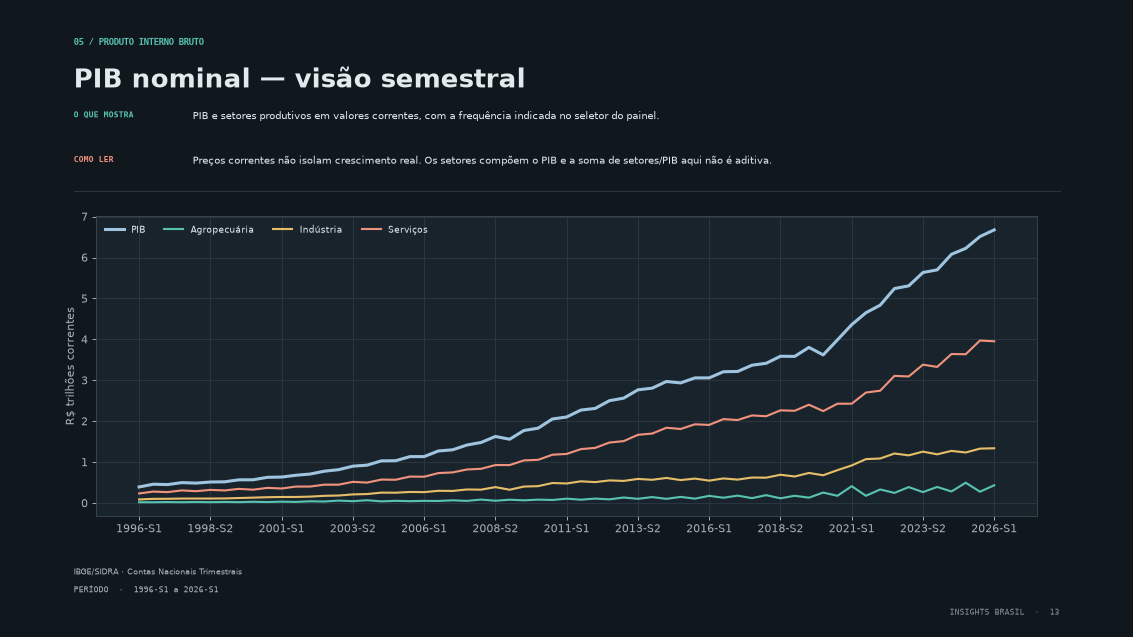

In [14]:
typ='semestre'
if typ=="trimestre":
    rows=D["pib"]["quarterly"]; labels=[r["trimestre"] for r in rows]; years=[r["ano"] for r in rows]
else:
    rows=[r for r in D["pib"]["aggregates"] if r["tipo_periodo"]==typ and r.get("periodo_completo")]
    labels=[r["periodo"] for r in rows]; years=[r["ano"] for r in rows]
fig,ax=make_page("05 / Produto Interno Bruto",'PIB nominal — visão semestral',
"PIB e setores produtivos em valores correntes, com a frequência indicada no seletor do painel.",
"Preços correntes não isolam crescimento real. Os setores compõem o PIB e a soma de setores/PIB aqui não é aditiva.","IBGE/SIDRA · Contas Nacionais Trimestrais",f"{labels[0]} a {labels[-1]}")
x=np.arange(len(rows))
for slug,name,color,width in [("pib","PIB",NAVY,2.6),("agropecuaria","Agropecuária",TEAL,1.8),("industria","Indústria",GOLD,1.8),("servicos","Serviços",CORAL,1.8)]:
    vals=[r.get(slug+"_nominal_milhoes")/1e6 if r.get(slug+"_nominal_milhoes") is not None else np.nan for r in rows]
    ax.plot(x,vals,color=color,lw=width,label=name)
categorical_ticks(ax,labels,14);ax.set_ylabel("R$ trilhões correntes");legend(ax,loc="upper left",ncol=4);finish(fig)

## PIB nominal — visão anual

**O que representa.** PIB a preços correntes e valores setoriais agregados por anual segundo as Contas Nacionais Trimestrais.

**Interpretação e importância.** Valores nominais misturam preços e quantidades. Agropecuária, indústria e serviços são parcelas da economia e aparecem para escala; não se somam novamente ao PIB. Os agregados anual e semestral somam trimestres.

**Para aprofundar.** Contas Nacionais, valor adicionado, preços correntes, índice de volume e deflator do PIB.

Fonte: IBGE/SIDRA · Contas Nacionais Trimestrais.

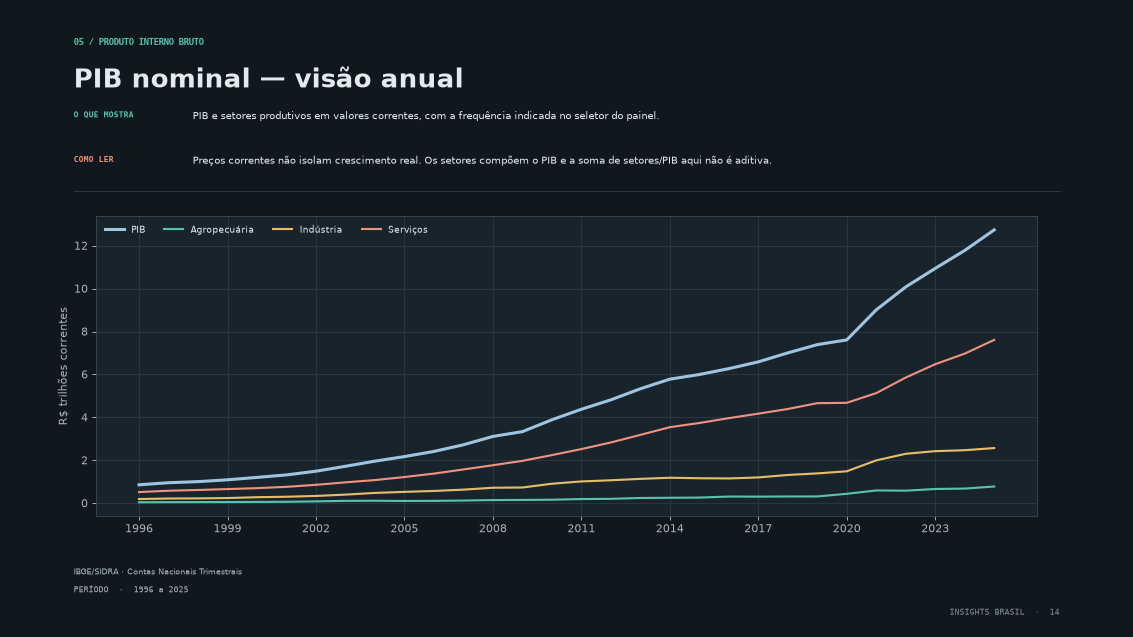

In [15]:
typ='ano'
if typ=="trimestre":
    rows=D["pib"]["quarterly"]; labels=[r["trimestre"] for r in rows]; years=[r["ano"] for r in rows]
else:
    rows=[r for r in D["pib"]["aggregates"] if r["tipo_periodo"]==typ and r.get("periodo_completo")]
    labels=[r["periodo"] for r in rows]; years=[r["ano"] for r in rows]
fig,ax=make_page("05 / Produto Interno Bruto",'PIB nominal — visão anual',
"PIB e setores produtivos em valores correntes, com a frequência indicada no seletor do painel.",
"Preços correntes não isolam crescimento real. Os setores compõem o PIB e a soma de setores/PIB aqui não é aditiva.","IBGE/SIDRA · Contas Nacionais Trimestrais",f"{labels[0]} a {labels[-1]}")
x=np.arange(len(rows))
for slug,name,color,width in [("pib","PIB",NAVY,2.6),("agropecuaria","Agropecuária",TEAL,1.8),("industria","Indústria",GOLD,1.8),("servicos","Serviços",CORAL,1.8)]:
    vals=[r.get(slug+"_nominal_milhoes")/1e6 if r.get(slug+"_nominal_milhoes") is not None else np.nan for r in rows]
    ax.plot(x,vals,color=color,lw=width,label=name)
categorical_ticks(ax,labels,14);ax.set_ylabel("R$ trilhões correntes");legend(ax,loc="upper left",ncol=4);finish(fig)

## Crescimento real do PIB — visão trimestral

**O que representa.** Variações reais do PIB e dos três setores por trimestral, usando índices de volume das Contas Nacionais.

**Interpretação e importância.** No trimestre, o IBGE publica a comparação com o período equivalente do ano anterior; o painel inclui também a taxa trimestral dessazonalizada do PIB. No semestre, a comparação é derivada; no ano, o acumulado é taxa publicada pelo IBGE.

**Para aprofundar.** Índices de volume, ajuste sazonal, efeito de base, crescimento acumulado e revisões das Contas Nacionais.

Fonte: IBGE/SIDRA · taxas de variação das Contas Nacionais.

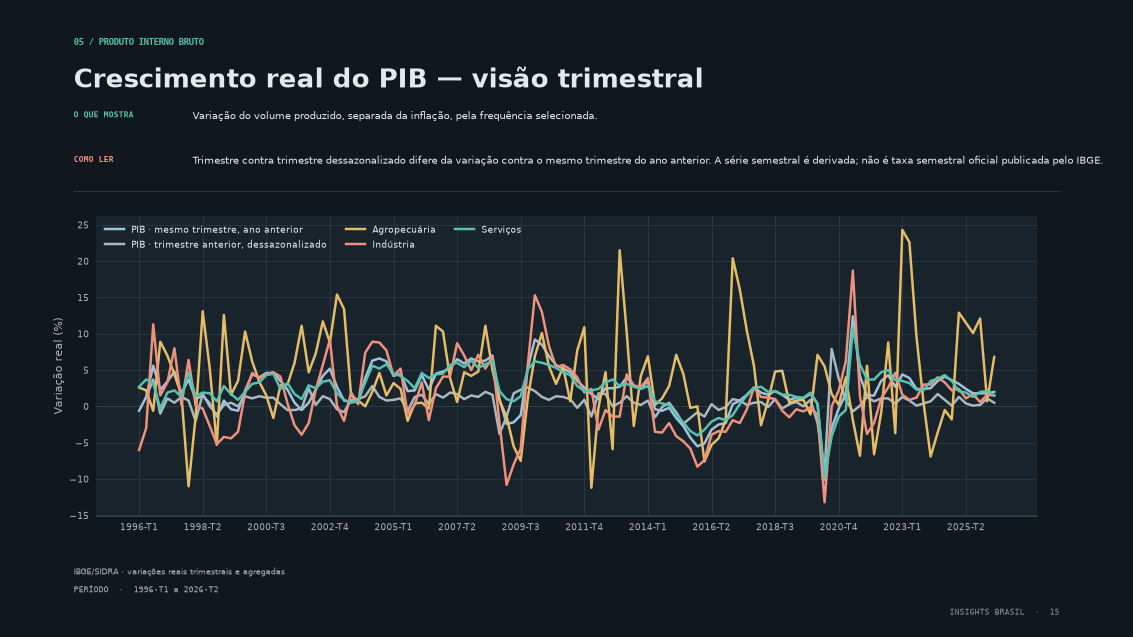

In [16]:
typ='trimestre'
if typ=="trimestre":
    rows=D["pib"]["quarterly"]; labels=[r["trimestre"] for r in rows]
    series=[("pib_yoy_percentual","PIB · mesmo trimestre, ano anterior",NAVY),("pib_qoq_sa_percentual","PIB · trimestre anterior, dessazonalizado",SLATE),("agropecuaria_yoy_percentual","Agropecuária",GOLD),("industria_yoy_percentual","Indústria",CORAL),("servicos_yoy_percentual","Serviços",TEAL)]
else:
    rows=[r for r in D["pib"]["aggregates"] if r["tipo_periodo"]==typ and r.get("periodo_completo")]
    labels=[r["periodo"] for r in rows]
    if typ=="semestre":
        series=[(s+"_real_semestre_derived_percentual",n,c) for s,n,c in [("pib","PIB",NAVY),("agropecuaria","Agropecuária",GOLD),("industria","Indústria",CORAL),("servicos","Serviços",TEAL)]]
    else:
        series=[(s+"_ytd_percentual",n,c) for s,n,c in [("pib","PIB",NAVY),("agropecuaria","Agropecuária",GOLD),("industria","Indústria",CORAL),("servicos","Serviços",TEAL)]]
fig,ax=make_page("05 / Produto Interno Bruto",'Crescimento real do PIB — visão trimestral',
"Variação do volume produzido, separada da inflação, pela frequência selecionada.",
"Trimestre contra trimestre dessazonalizado difere da variação contra o mesmo trimestre do ano anterior. A série semestral é derivada; não é taxa semestral oficial publicada pelo IBGE.","IBGE/SIDRA · variações reais trimestrais e agregadas",f"{labels[0]} a {labels[-1]}")
x=np.arange(len(rows))
for field,name,color in series:ax.plot(x,[r.get(field) if r.get(field) is not None else np.nan for r in rows],color=color,lw=2.1,label=name)
categorical_ticks(ax,labels,14);ax.set_ylabel("Variação real (%)");axis_style(ax,percent=True);legend(ax,loc="upper left",ncol=3);finish(fig)

## Crescimento real do PIB — visão semestral

**O que representa.** Variações reais do PIB e dos três setores por semestral, usando índices de volume das Contas Nacionais.

**Interpretação e importância.** No trimestre, o IBGE publica a comparação com o período equivalente do ano anterior; o painel inclui também a taxa trimestral dessazonalizada do PIB. No semestre, a comparação é derivada; no ano, o acumulado é taxa publicada pelo IBGE.

**Para aprofundar.** Índices de volume, ajuste sazonal, efeito de base, crescimento acumulado e revisões das Contas Nacionais.

Fonte: IBGE/SIDRA · taxas de variação das Contas Nacionais.

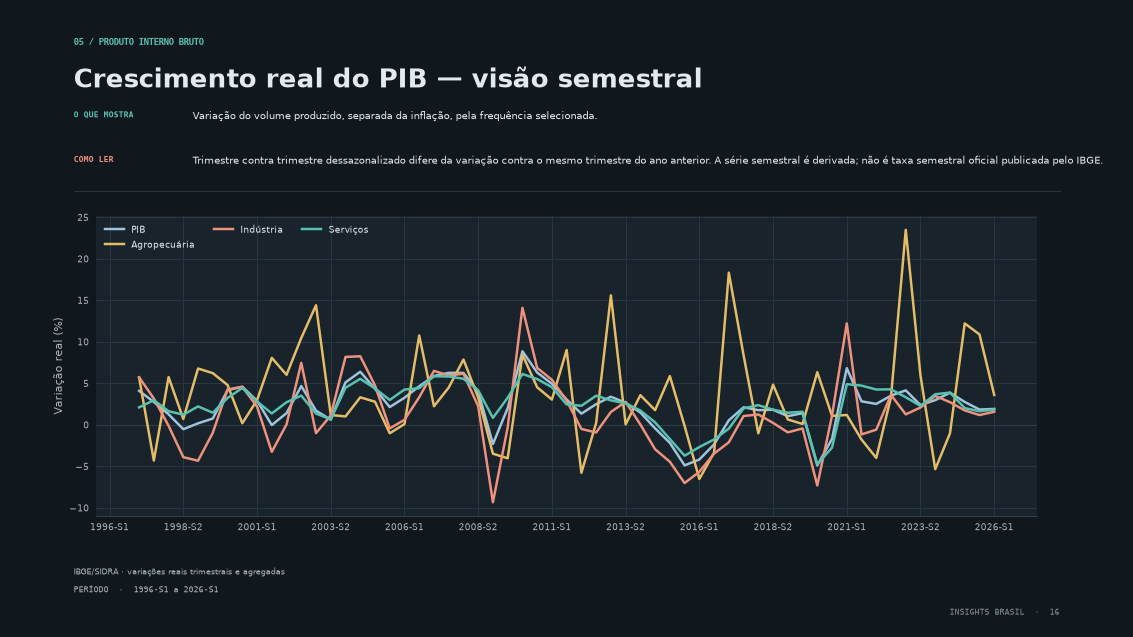

In [17]:
typ='semestre'
if typ=="trimestre":
    rows=D["pib"]["quarterly"]; labels=[r["trimestre"] for r in rows]
    series=[("pib_yoy_percentual","PIB · mesmo trimestre, ano anterior",NAVY),("pib_qoq_sa_percentual","PIB · trimestre anterior, dessazonalizado",SLATE),("agropecuaria_yoy_percentual","Agropecuária",GOLD),("industria_yoy_percentual","Indústria",CORAL),("servicos_yoy_percentual","Serviços",TEAL)]
else:
    rows=[r for r in D["pib"]["aggregates"] if r["tipo_periodo"]==typ and r.get("periodo_completo")]
    labels=[r["periodo"] for r in rows]
    if typ=="semestre":
        series=[(s+"_real_semestre_derived_percentual",n,c) for s,n,c in [("pib","PIB",NAVY),("agropecuaria","Agropecuária",GOLD),("industria","Indústria",CORAL),("servicos","Serviços",TEAL)]]
    else:
        series=[(s+"_ytd_percentual",n,c) for s,n,c in [("pib","PIB",NAVY),("agropecuaria","Agropecuária",GOLD),("industria","Indústria",CORAL),("servicos","Serviços",TEAL)]]
fig,ax=make_page("05 / Produto Interno Bruto",'Crescimento real do PIB — visão semestral',
"Variação do volume produzido, separada da inflação, pela frequência selecionada.",
"Trimestre contra trimestre dessazonalizado difere da variação contra o mesmo trimestre do ano anterior. A série semestral é derivada; não é taxa semestral oficial publicada pelo IBGE.","IBGE/SIDRA · variações reais trimestrais e agregadas",f"{labels[0]} a {labels[-1]}")
x=np.arange(len(rows))
for field,name,color in series:ax.plot(x,[r.get(field) if r.get(field) is not None else np.nan for r in rows],color=color,lw=2.1,label=name)
categorical_ticks(ax,labels,14);ax.set_ylabel("Variação real (%)");axis_style(ax,percent=True);legend(ax,loc="upper left",ncol=3);finish(fig)

## Crescimento real do PIB — visão anual

**O que representa.** Variações reais do PIB e dos três setores por anual, usando índices de volume das Contas Nacionais.

**Interpretação e importância.** No trimestre, o IBGE publica a comparação com o período equivalente do ano anterior; o painel inclui também a taxa trimestral dessazonalizada do PIB. No semestre, a comparação é derivada; no ano, o acumulado é taxa publicada pelo IBGE.

**Para aprofundar.** Índices de volume, ajuste sazonal, efeito de base, crescimento acumulado e revisões das Contas Nacionais.

Fonte: IBGE/SIDRA · taxas de variação das Contas Nacionais.

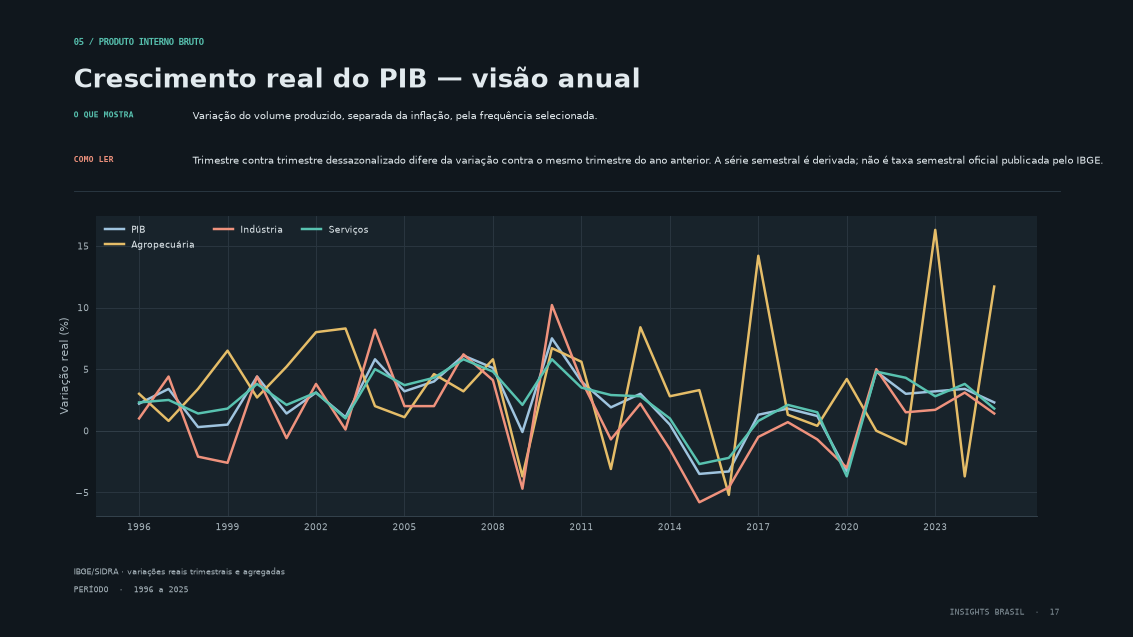

In [18]:
typ='ano'
if typ=="trimestre":
    rows=D["pib"]["quarterly"]; labels=[r["trimestre"] for r in rows]
    series=[("pib_yoy_percentual","PIB · mesmo trimestre, ano anterior",NAVY),("pib_qoq_sa_percentual","PIB · trimestre anterior, dessazonalizado",SLATE),("agropecuaria_yoy_percentual","Agropecuária",GOLD),("industria_yoy_percentual","Indústria",CORAL),("servicos_yoy_percentual","Serviços",TEAL)]
else:
    rows=[r for r in D["pib"]["aggregates"] if r["tipo_periodo"]==typ and r.get("periodo_completo")]
    labels=[r["periodo"] for r in rows]
    if typ=="semestre":
        series=[(s+"_real_semestre_derived_percentual",n,c) for s,n,c in [("pib","PIB",NAVY),("agropecuaria","Agropecuária",GOLD),("industria","Indústria",CORAL),("servicos","Serviços",TEAL)]]
    else:
        series=[(s+"_ytd_percentual",n,c) for s,n,c in [("pib","PIB",NAVY),("agropecuaria","Agropecuária",GOLD),("industria","Indústria",CORAL),("servicos","Serviços",TEAL)]]
fig,ax=make_page("05 / Produto Interno Bruto",'Crescimento real do PIB — visão anual',
"Variação do volume produzido, separada da inflação, pela frequência selecionada.",
"Trimestre contra trimestre dessazonalizado difere da variação contra o mesmo trimestre do ano anterior. A série semestral é derivada; não é taxa semestral oficial publicada pelo IBGE.","IBGE/SIDRA · variações reais trimestrais e agregadas",f"{labels[0]} a {labels[-1]}")
x=np.arange(len(rows))
for field,name,color in series:ax.plot(x,[r.get(field) if r.get(field) is not None else np.nan for r in rows],color=color,lw=2.1,label=name)
categorical_ticks(ax,labels,14);ax.set_ylabel("Variação real (%)");axis_style(ax,percent=True);legend(ax,loc="upper left",ncol=3);finish(fig)

## Componentes da despesa do PIB — visão trimestral

**O que representa.** Crescimento real do consumo das famílias e do governo, formação de capital, exportações e importações por trimestral.

**Interpretação e importância.** Componentes da ótica da despesa descrevem usos e fluxos do PIB. Importações entram com sinal negativo na identidade contábil, mas a taxa de crescimento da série não é sua contribuição direta ao crescimento total.

**Para aprofundar.** Identidade do PIB pela despesa, formação de capital, exportações líquidas, estoques e decomposição em pontos percentuais.

Fonte: IBGE/SIDRA · componentes da despesa nas Contas Nacionais.

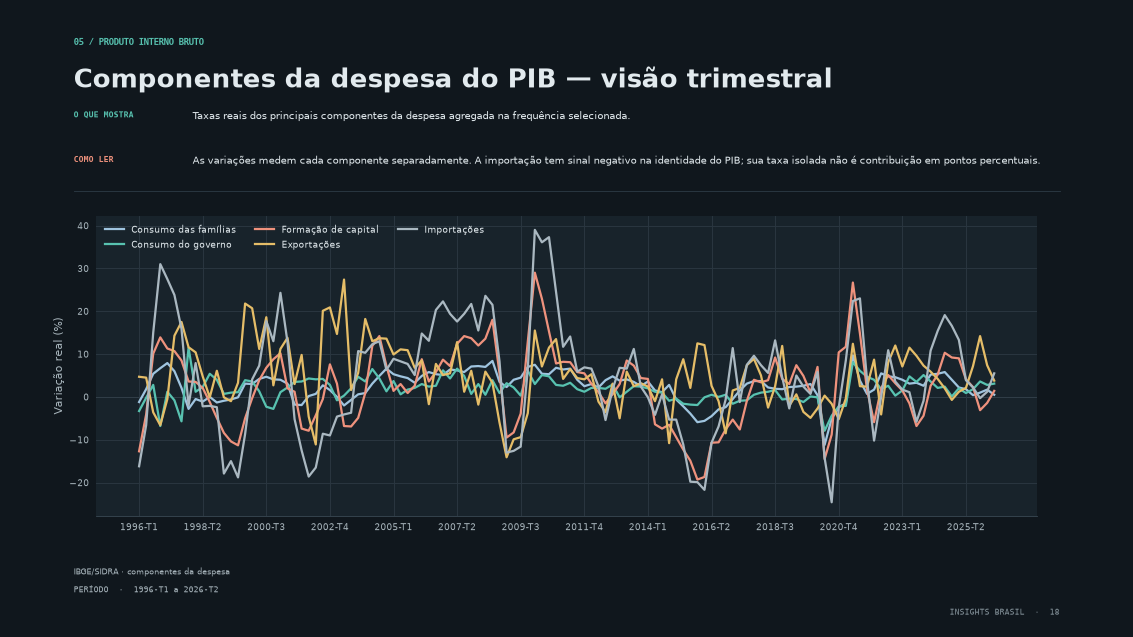

In [19]:
typ='trimestre'
if typ=="trimestre":
    rows=D["pib"]["quarterly"];labels=[r["trimestre"] for r in rows];suffix="_yoy_percentual"
else:
    rows=[r for r in D["pib"]["aggregates"] if r["tipo_periodo"]==typ and r.get("periodo_completo")];labels=[r["periodo"] for r in rows]
    suffix="_real_semestre_derived_percentual" if typ=="semestre" else "_ytd_percentual"
items=[("consumo_familias","Consumo das famílias",NAVY),("consumo_governo","Consumo do governo",TEAL),("formacao_capital","Formação de capital",CORAL),("exportacoes","Exportações",GOLD),("importacoes","Importações",SLATE)]
fig,ax=make_page("05 / Produto Interno Bruto",'Componentes da despesa do PIB — visão trimestral',
"Taxas reais dos principais componentes da despesa agregada na frequência selecionada.",
"As variações medem cada componente separadamente. A importação tem sinal negativo na identidade do PIB; sua taxa isolada não é contribuição em pontos percentuais.","IBGE/SIDRA · componentes da despesa",f"{labels[0]} a {labels[-1]}")
x=np.arange(len(rows))
for slug,name,color in items:ax.plot(x,[r.get(slug+suffix) if r.get(slug+suffix) is not None else np.nan for r in rows],color=color,lw=1.9,label=name)
categorical_ticks(ax,labels,14);ax.set_ylabel("Variação real (%)");axis_style(ax,percent=True);legend(ax,loc="upper left",ncol=3);finish(fig)

## Componentes da despesa do PIB — visão semestral

**O que representa.** Crescimento real do consumo das famílias e do governo, formação de capital, exportações e importações por semestral.

**Interpretação e importância.** Componentes da ótica da despesa descrevem usos e fluxos do PIB. Importações entram com sinal negativo na identidade contábil, mas a taxa de crescimento da série não é sua contribuição direta ao crescimento total.

**Para aprofundar.** Identidade do PIB pela despesa, formação de capital, exportações líquidas, estoques e decomposição em pontos percentuais.

Fonte: IBGE/SIDRA · componentes da despesa nas Contas Nacionais.

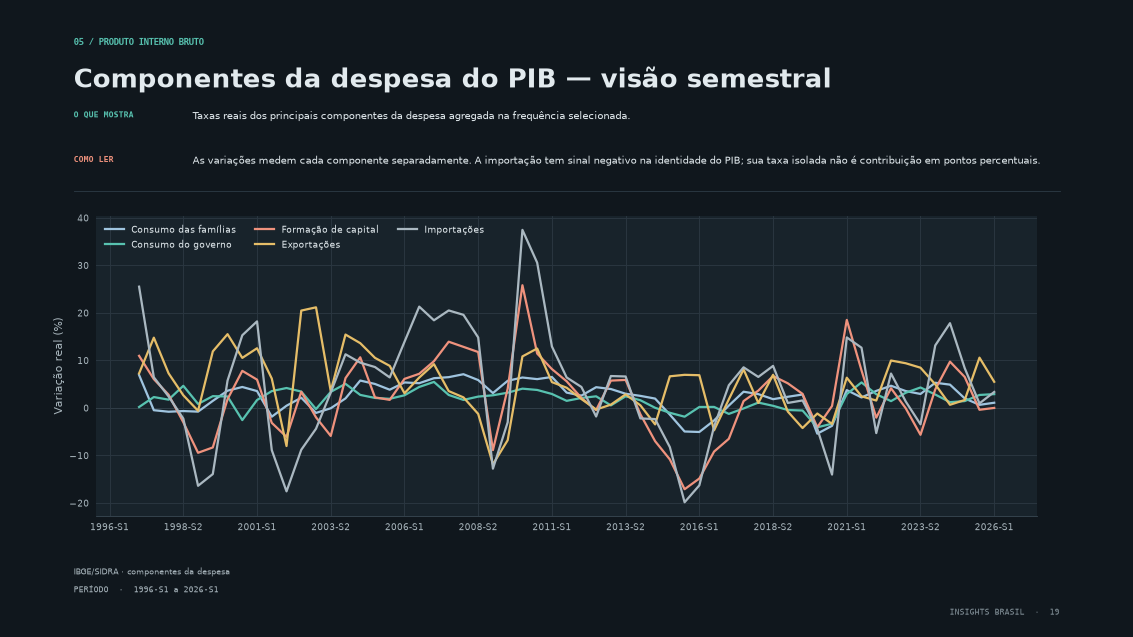

In [20]:
typ='semestre'
if typ=="trimestre":
    rows=D["pib"]["quarterly"];labels=[r["trimestre"] for r in rows];suffix="_yoy_percentual"
else:
    rows=[r for r in D["pib"]["aggregates"] if r["tipo_periodo"]==typ and r.get("periodo_completo")];labels=[r["periodo"] for r in rows]
    suffix="_real_semestre_derived_percentual" if typ=="semestre" else "_ytd_percentual"
items=[("consumo_familias","Consumo das famílias",NAVY),("consumo_governo","Consumo do governo",TEAL),("formacao_capital","Formação de capital",CORAL),("exportacoes","Exportações",GOLD),("importacoes","Importações",SLATE)]
fig,ax=make_page("05 / Produto Interno Bruto",'Componentes da despesa do PIB — visão semestral',
"Taxas reais dos principais componentes da despesa agregada na frequência selecionada.",
"As variações medem cada componente separadamente. A importação tem sinal negativo na identidade do PIB; sua taxa isolada não é contribuição em pontos percentuais.","IBGE/SIDRA · componentes da despesa",f"{labels[0]} a {labels[-1]}")
x=np.arange(len(rows))
for slug,name,color in items:ax.plot(x,[r.get(slug+suffix) if r.get(slug+suffix) is not None else np.nan for r in rows],color=color,lw=1.9,label=name)
categorical_ticks(ax,labels,14);ax.set_ylabel("Variação real (%)");axis_style(ax,percent=True);legend(ax,loc="upper left",ncol=3);finish(fig)

## Componentes da despesa do PIB — visão anual

**O que representa.** Crescimento real do consumo das famílias e do governo, formação de capital, exportações e importações por anual.

**Interpretação e importância.** Componentes da ótica da despesa descrevem usos e fluxos do PIB. Importações entram com sinal negativo na identidade contábil, mas a taxa de crescimento da série não é sua contribuição direta ao crescimento total.

**Para aprofundar.** Identidade do PIB pela despesa, formação de capital, exportações líquidas, estoques e decomposição em pontos percentuais.

Fonte: IBGE/SIDRA · componentes da despesa nas Contas Nacionais.

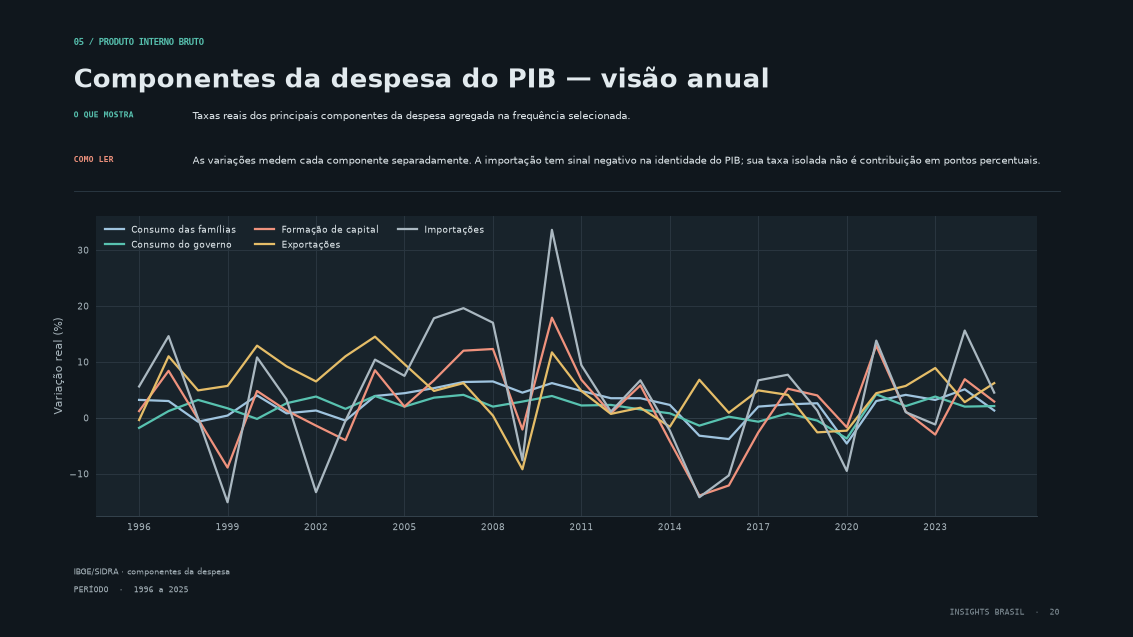

In [21]:
typ='ano'
if typ=="trimestre":
    rows=D["pib"]["quarterly"];labels=[r["trimestre"] for r in rows];suffix="_yoy_percentual"
else:
    rows=[r for r in D["pib"]["aggregates"] if r["tipo_periodo"]==typ and r.get("periodo_completo")];labels=[r["periodo"] for r in rows]
    suffix="_real_semestre_derived_percentual" if typ=="semestre" else "_ytd_percentual"
items=[("consumo_familias","Consumo das famílias",NAVY),("consumo_governo","Consumo do governo",TEAL),("formacao_capital","Formação de capital",CORAL),("exportacoes","Exportações",GOLD),("importacoes","Importações",SLATE)]
fig,ax=make_page("05 / Produto Interno Bruto",'Componentes da despesa do PIB — visão anual',
"Taxas reais dos principais componentes da despesa agregada na frequência selecionada.",
"As variações medem cada componente separadamente. A importação tem sinal negativo na identidade do PIB; sua taxa isolada não é contribuição em pontos percentuais.","IBGE/SIDRA · componentes da despesa",f"{labels[0]} a {labels[-1]}")
x=np.arange(len(rows))
for slug,name,color in items:ax.plot(x,[r.get(slug+suffix) if r.get(slug+suffix) is not None else np.nan for r in rows],color=color,lw=1.9,label=name)
categorical_ticks(ax,labels,14);ax.set_ylabel("Variação real (%)");axis_style(ax,percent=True);legend(ax,loc="upper left",ncol=3);finish(fig)

## Arrecadação federal por mês

**O que representa.** Receitas federais totais por mês, com a parcela administrada pela Receita Federal detalhada nos anos mais recentes.

**Interpretação e importância.** Valores são nominais e não corrigidos pelo IPCA. Variações refletem inflação, atividade, composição e mudanças legais. Arrecadação federal não é a carga tributária consolidada nem a receita líquida após transferências.

**Para aprofundar.** Receita corrente, tributos, repartição de receitas, carga tributária e resultado fiscal.

Fonte: Receita Federal · série histórica e anexos mensais.

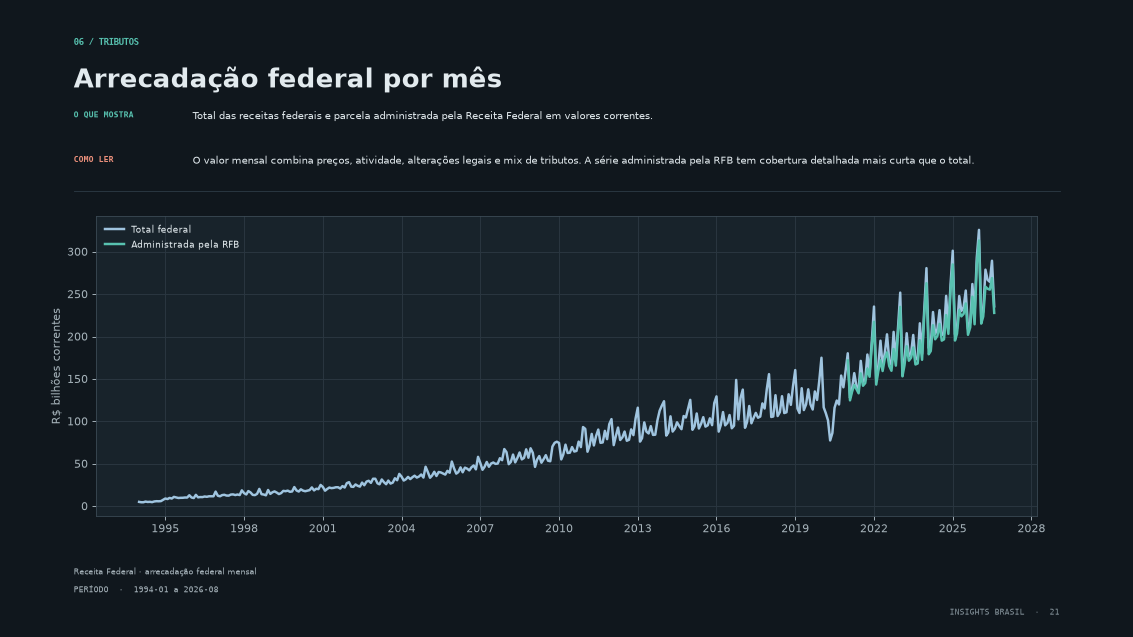

In [22]:
rows=[r for r in D["taxes"]["monthly"] if r.get("arrecadacao_total_federal_milhoes") is not None]
fig,ax=make_page("06 / Tributos","Arrecadação federal por mês",
"Total das receitas federais e parcela administrada pela Receita Federal em valores correntes.",
"O valor mensal combina preços, atividade, alterações legais e mix de tributos. A série administrada pela RFB tem cobertura detalhada mais curta que o total.","Receita Federal · arrecadação federal mensal",f"{rows[0]['data']} a {rows[-1]['data']}")
dates=pd.to_datetime([r["data"]+"-01" for r in rows])
for key,name,color in [("arrecadacao_total_federal_milhoes","Total federal",NAVY),("arrecadacao_rfb_administrada_milhoes","Administrada pela RFB",TEAL)]:
    ax.plot(dates,[r[key]/1000 if r.get(key) is not None else np.nan for r in rows],color=color,lw=2.1,label=name)
ax.set_ylabel("R$ bilhões correntes");year_ticks(ax,3);legend(ax,loc="upper left");finish(fig)

## Carga tributária bruta do Governo Geral

**O que representa.** Carga tributária anual do Governo Geral e suas parcelas por Governo Central, estados e municípios como proporção do PIB.

**Interpretação e importância.** É uma série anual consolidada das três esferas, distinta da arrecadação federal mensal. O percentual do PIB relaciona tributos arrecadados à dimensão da economia.

**Para aprofundar.** Carga tributária bruta, federalismo fiscal, incidência tributária e comparabilidade do PIB.

Fonte: Tesouro Nacional · carga tributária bruta do Governo Geral.

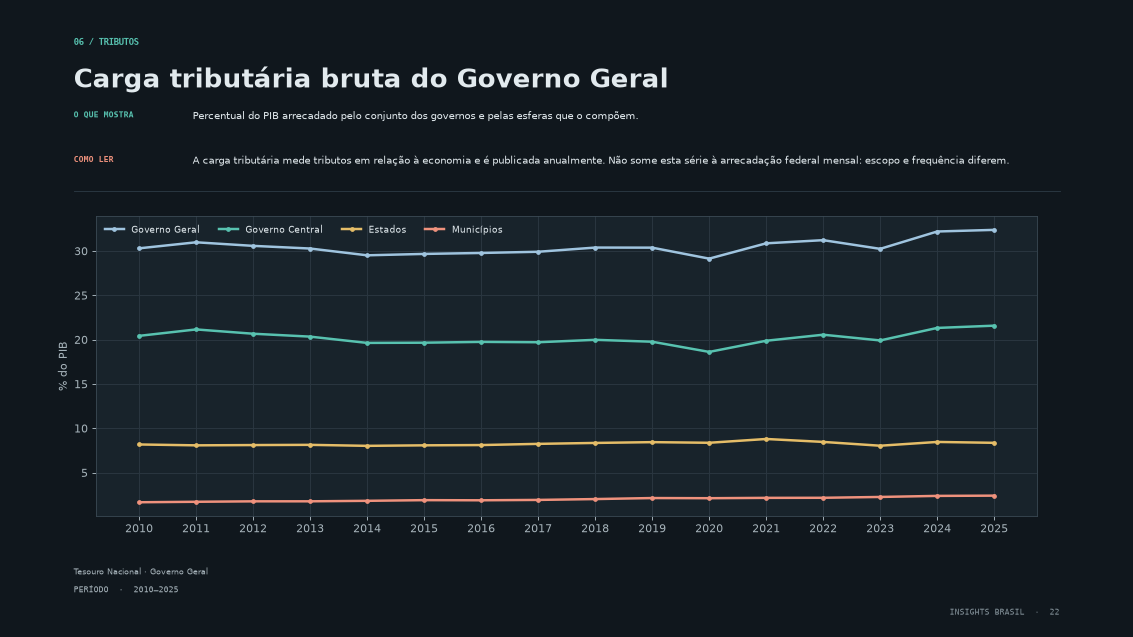

In [23]:
rows=D["taxes"]["general_annual"];years=[r["ano"] for r in rows]
fig,ax=make_page("06 / Tributos","Carga tributária bruta do Governo Geral",
"Percentual do PIB arrecadado pelo conjunto dos governos e pelas esferas que o compõem.",
"A carga tributária mede tributos em relação à economia e é publicada anualmente. Não some esta série à arrecadação federal mensal: escopo e frequência diferem.","Tesouro Nacional · Governo Geral",f"{years[0]}–{years[-1]}")
for key,name,color in [("governo_geral_percentual_pib","Governo Geral",NAVY),("governo_central_percentual_pib","Governo Central",TEAL),("governos_estaduais_percentual_pib","Estados",GOLD),("governos_municipais_percentual_pib","Municípios",CORAL)]:
    ax.plot(years,[r.get(key) for r in rows],color=color,lw=2.1,marker="o",ms=3,label=name)
ax.set_ylabel("% do PIB");ax.set_xticks(years);legend(ax,loc="upper left",ncol=4);finish(fig)

## Poder de compra do real desde julho de 1994

**O que representa.** Valor, em cada mês, de uma cesta que custava R$ 100 no início da série do Plano Real, atualizada com a inflação acumulada pelo IPCA.

**Interpretação e importância.** O IPCA representa a variação média de preços ao consumidor, não uma cesta individual nem a taxa de câmbio. Inflação acumulada e perda do poder de compra são medidas relacionadas, mas percentualmente diferentes.

**Para aprofundar.** Composição de índices de preços, inflação acumulada, renda real e diferença entre poder de compra e câmbio.

Fonte: IBGE · IPCA mensal, obtido pela série SGS 433 do Banco Central.

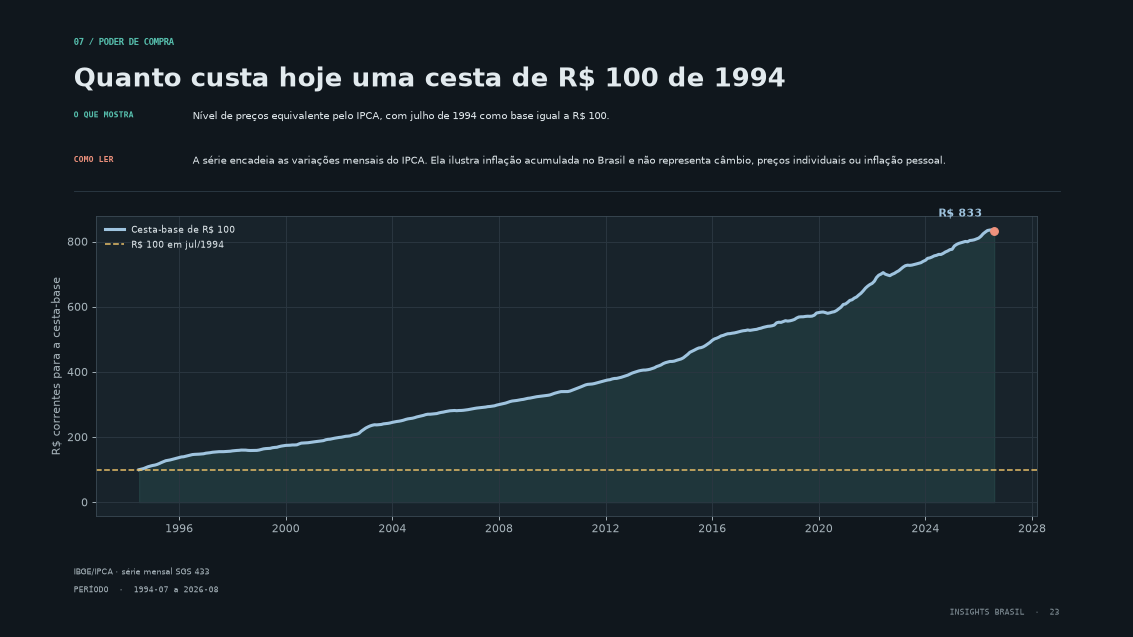

In [24]:
rows=D["purchasing_power"]["monthly"]
fig,ax=make_page("07 / Poder de compra","Quanto custa hoje uma cesta de R$ 100 de 1994",
"Nível de preços equivalente pelo IPCA, com julho de 1994 como base igual a R$ 100.",
"A série encadeia as variações mensais do IPCA. Ela ilustra inflação acumulada no Brasil e não representa câmbio, preços individuais ou inflação pessoal.","IBGE/IPCA · série mensal SGS 433",f"{rows[0]['data']} a {rows[-1]['data']}")
dates=pd.to_datetime([r["data"]+"-01" for r in rows]); values=[r["preco_cesta_r_100_jul_1994"] for r in rows]
ax.fill_between(dates,values,color=TEAL,alpha=.12);ax.plot(dates,values,color=NAVY,lw=2.6,label="Cesta-base de R$ 100")
ax.axhline(100,color=GOLD,lw=1.3,ls="--",label="R$ 100 em jul/1994")
ax.scatter([dates[-1]],[values[-1]],color=CORAL,s=42,zorder=4)
ax.annotate("R$ "+br(values[-1],0),(dates[-1],values[-1]),xytext=(-10,12),textcoords="offset points",ha="right",color=NAVY,weight="bold")
ax.set_ylabel("R$ correntes para a cesta-base");year_ticks(ax,4);legend(ax,loc="upper left");finish(fig)

## Fontes, método e limites

O estudo usa cópias locais das fontes oficiais preservadas em `data/raw/` e tabelas tratadas em `data/processed/`. O painel e este notebook consomem o bundle comprimido `web/src/assets/data/dashboard.json.gz`; não há chamadas a serviços externos durante a geração dos gráficos.

- **Tesouro Nacional:** estoque, fatores, juros apropriados e execução da dívida pública federal.
- **Banco Central:** DBGG/PIB, DLGG/PIB e IPCA (séries SGS).
- **IBGE/SIDRA:** Contas Nacionais Trimestrais, índices de volume e taxas oficiais.
- **SIOP:** execução paga por função e classificação GND 4.
- **MDS/VIS DATA:** série agregada de beneficiários do BPC e comparação de programas.
- **Receita Federal e Tesouro Nacional:** arrecadação federal mensal e carga tributária do Governo Geral.

As taxas nominais não são taxas reais. DPF e DBGG têm perímetros distintos. A comparação de transferências sociais usa unidades de cobertura diferentes. Resultados históricos podem ser revisados pelas fontes. Consulte [data/README.md](../data/README.md) para arquivos, métodos e cobertura de cada série.

In [25]:
PDF.close()
print(f"PDF completo gerado a partir deste notebook: {OUT.relative_to(ROOT)}")
print(f"Páginas: {PAGE} · tamanho: {OUT.stat().st_size/1024/1024:.2f} MB")

PDF completo gerado a partir deste notebook: artifacts/apresentacao_insights_brasil.pdf
Páginas: 23 · tamanho: 0.21 MB
